# Trust Region Q Adjoint Matching - Executable Report

This notebook is both the **paper implementation control surface** and the **report**. It orchestrates the full TRQAM pipeline for a single task:

1. **BC pretraining** (run once) - a flow policy trained with behavior cloning.
2. **Offline RL fine-tuning** - `TRQAM` and `QAM`, each over **4 seeds**, launched **concurrently**, one GPU per run (run as sequential per-algorithm waves when fewer GPUs are free).

Every run evaluates the success rate (SR) **inline on its own GPU** every 1K steps over 50 episodes (no separate eval GPU), keeps only the latest checkpoint (the previous one is deleted), and appends `eval.csv`. The result cells aggregate the 4 seeds into TRQAM-vs-QAM success-rate curves (mean +/- std).

In [1]:
# Report display controls. Keep REPORT_MODE=False while working in Jupyter.
REPORT_MODE = False

from IPython.display import HTML, display

REPORT_CSS = r'''
<style>
:root {
  --trqam-text: #1f2328;
  --trqam-muted: #57606a;
  --trqam-border: #d0d7de;
  --trqam-accent: #0969da;
  --trqam-bg: #ffffff;
  --trqam-soft: #f6f8fa;
}
body, .jp-Notebook, .notebook_app {
  color: var(--trqam-text);
}
.trqam-callout {
  border-left: 4px solid var(--trqam-accent);
  background: var(--trqam-soft);
  padding: 12px 14px;
  margin: 10px 0 16px;
}
.trqam-kpi-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(150px, 1fr));
  gap: 10px;
  margin: 12px 0 18px;
}
.trqam-kpi {
  border: 1px solid var(--trqam-border);
  border-radius: 6px;
  padding: 10px 12px;
  background: var(--trqam-bg);
}
.trqam-kpi .label {
  color: var(--trqam-muted);
  font-size: 12px;
  margin-bottom: 4px;
}
.trqam-kpi .value {
  font-weight: 650;
  font-size: 18px;
}
.trqam-report h2, .trqam-report h3 {
  margin-top: 18px;
}
.trqam-report table, table.dataframe, .report-table {
  border-collapse: collapse;
  width: 100%;
  font-size: 13px;
}
.trqam-report th, .trqam-report td, table.dataframe th, table.dataframe td, .report-table th, .report-table td {
  border: 1px solid var(--trqam-border);
  padding: 6px 8px;
  text-align: left;
  vertical-align: top;
}
.trqam-report th, table.dataframe th, .report-table th {
  background: var(--trqam-soft);
}
.trqam-muted { color: var(--trqam-muted); }
@media print {
  .jp-Toolbar, .jp-NotebookPanel-toolbar, .jp-Cell-inputWrapper, .jp-InputPrompt, .jp-OutputPrompt, div.input, .prompt {
    display: none !important;
  }
}
</style>
'''

HIDE_CODE_CSS = r'''
<style id="trqam-hide-code">
.jp-Cell-inputWrapper, .jp-InputPrompt, .jp-OutputPrompt, div.input, .prompt {
  display: none !important;
}
</style>
'''

SHOW_CODE_CSS = r'''
<style id="trqam-show-code">
.jp-Cell-inputWrapper, .jp-InputPrompt, .jp-OutputPrompt, div.input, .prompt {
  display: revert !important;
}
.jp-Cell-inputWrapper {
  display: flex !important;
}
</style>
<script>
document.getElementById('trqam-hide-code')?.remove();
</script>
'''

if REPORT_MODE:
    display(HTML(REPORT_CSS + HIDE_CODE_CSS))
else:
    display(HTML(REPORT_CSS + SHOW_CODE_CSS))


## 1. Background

TRQAM fine-tunes a pretrained flow policy with off-policy RL while constraining the updated policy to stay close to the base policy under a path-space KL trust region. The Q-function action gradient is used as an adjoint signal for improving the policy vector field. When the estimated KL exceeds the configured budget, dual descent increases the trust-region coefficient and makes the policy update more conservative.

The paper pipeline has two stages.

1. Train a flow policy with behavior cloning by setting `bc_only=True`.
2. Load the BC checkpoint as `pretrained_actor_path` and fine-tune with TRQAM.


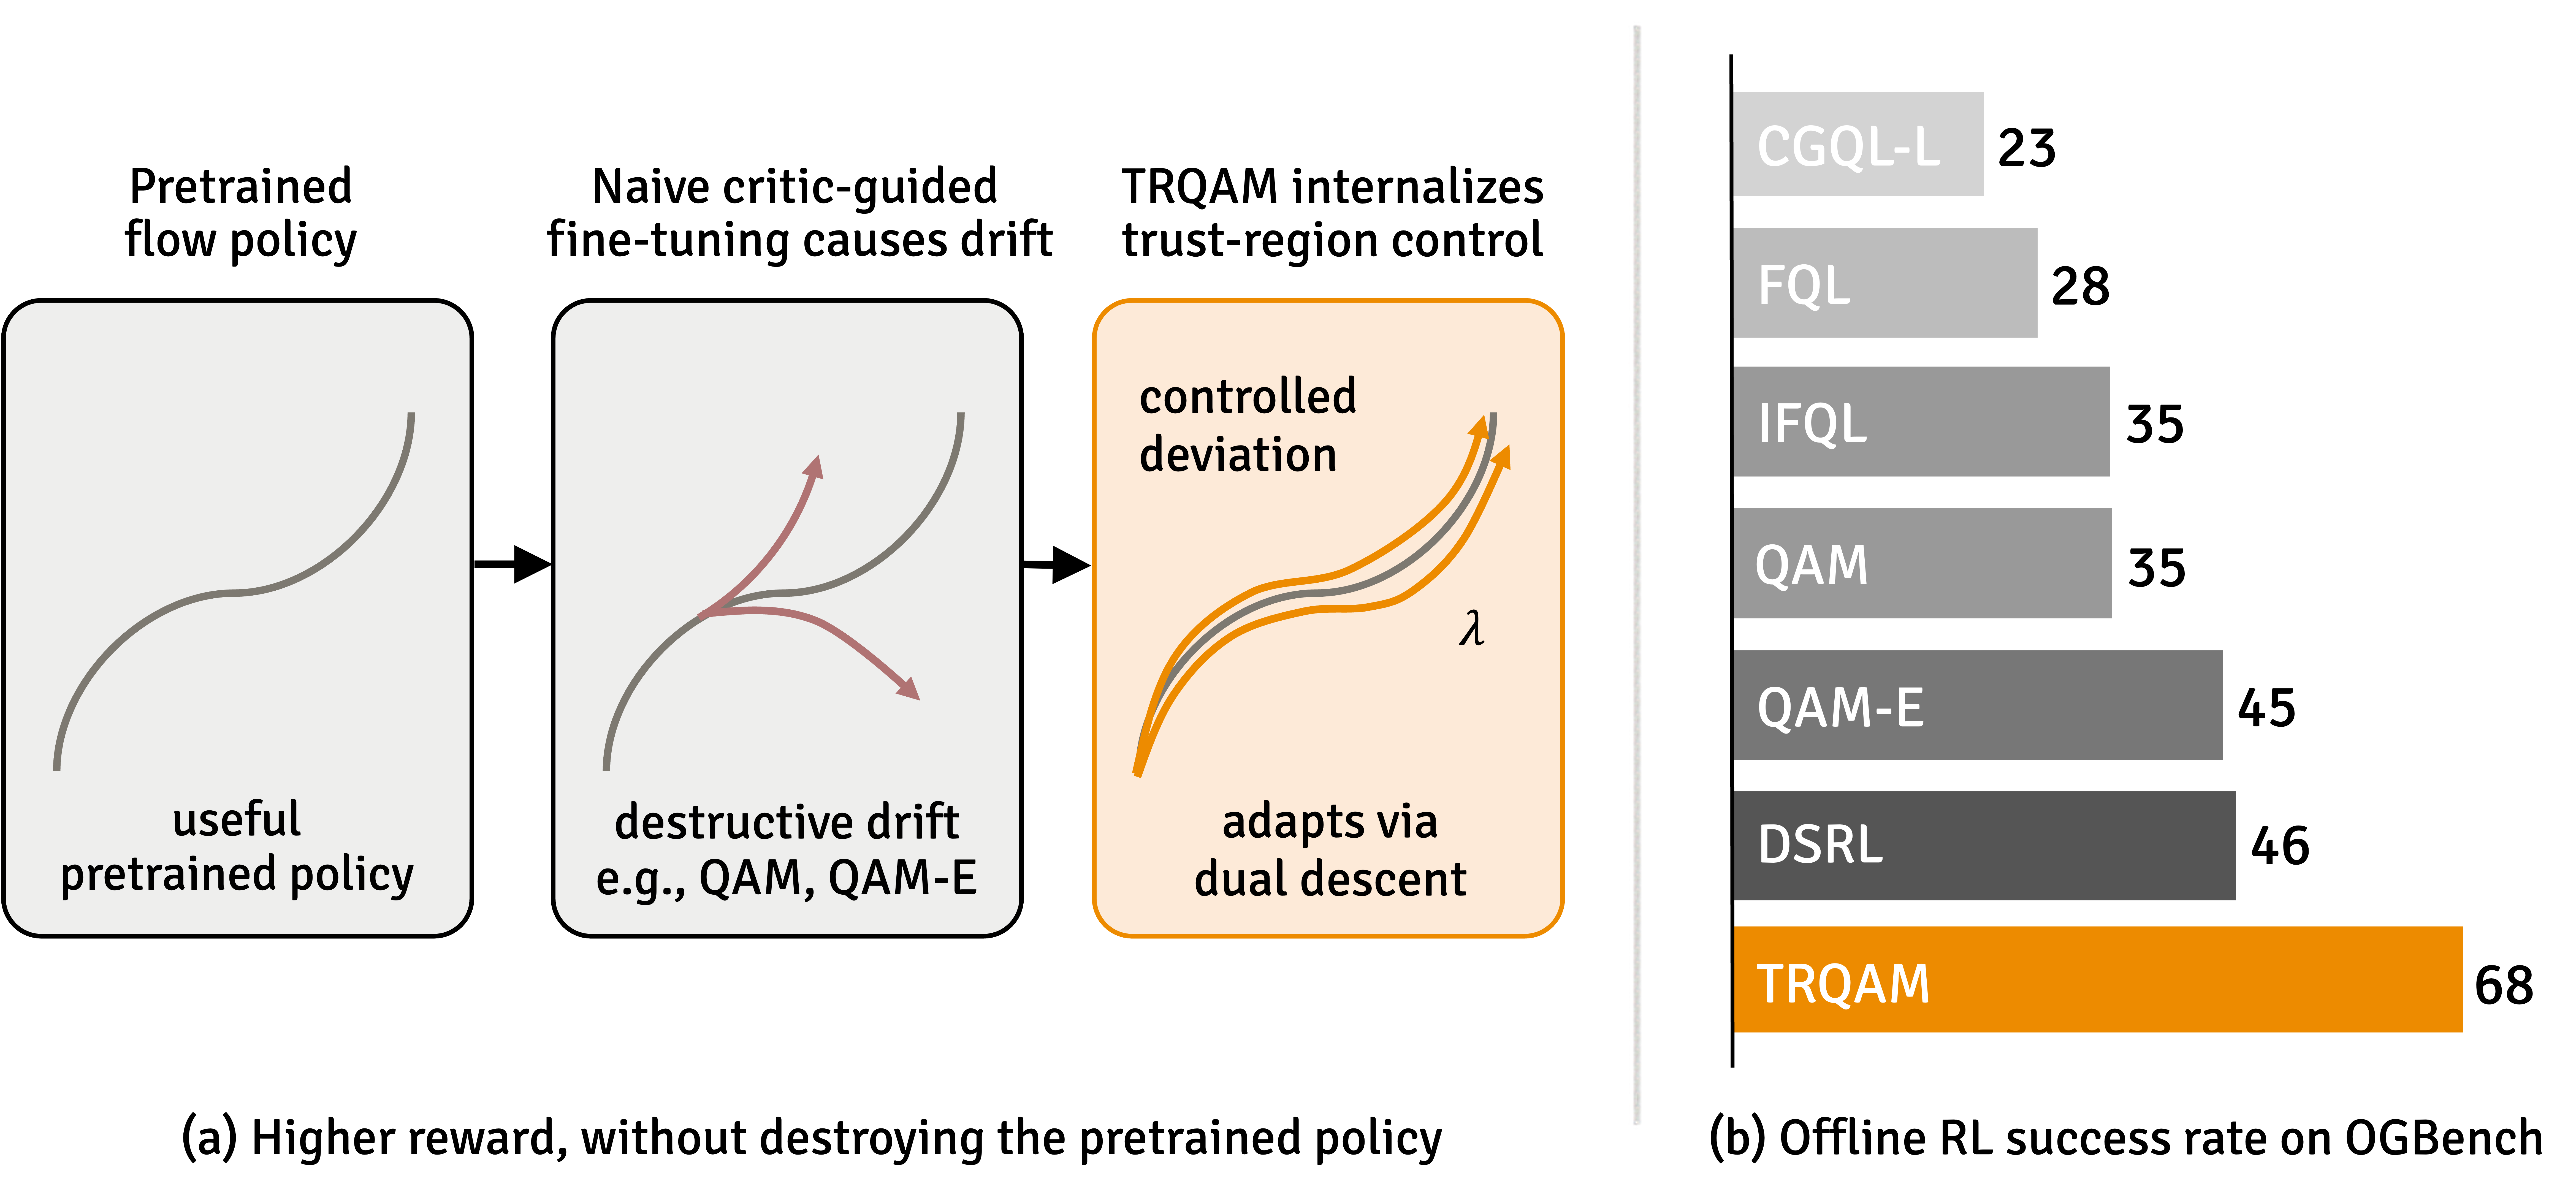

In [2]:
from pathlib import Path
from IPython.display import Image, Markdown, display

main_figure = Path('assets/Main_figure.png')
if main_figure.exists():
    display(Image(filename=str(main_figure)))
else:
    display(Markdown('_Main figure image was not found at `assets/Main_figure.png`._'))


## 2. Runtime Assumptions

Run from the repository root with the `TRQAM Conda (GPU)` kernel. The **orchestrator kernel runs on CPU** (`JAX_PLATFORMS=cpu`) so it never occupies a GPU; every training/eval run is launched as a subprocess pinned to a single physical GPU through `CUDA_VISIBLE_DEVICES`. Each worker sets `MUJOCO_GL=egl`, `WANDB_MODE=disabled`, and `XLA_PYTHON_CLIENT_PREALLOCATE=false`.

The default plan uses physical GPUs `0-7`: `TRQAM` seeds on GPUs 0-3 and `QAM` seeds on GPUs 4-7. BC runs first on GPU 0, then the eight RL runs launch together.

In [3]:
import importlib.util
import os
import sys
from pathlib import Path

# Orchestrator kernel stays on CPU; GPU work happens in per-run subprocesses.
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
os.environ.setdefault('WANDB_MODE', 'disabled')
os.environ.setdefault('MUJOCO_GL', 'egl')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

ROOT = Path.cwd()
if not (ROOT / 'main.py').exists() and (ROOT / 'trqam' / 'main.py').exists():
    ROOT = ROOT / 'trqam'

required_packages = ['jax', 'flax', 'distrax', 'pandas', 'matplotlib', 'tqdm', 'ml_collections', 'ogbench']
missing_packages = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing_packages:
    raise RuntimeError(
        'Missing packages: ' + ', '.join(missing_packages) + '\n'
        f'Current Python: {sys.executable}\n'
        f'Current prefix: {sys.prefix}\n'
        'Select the TRQAM GPU kernel, then restart the kernel and run from the top.'
    )

import base64
import glob
import html
import json
import pickle
import random
import re
import shutil
import subprocess
import time
from collections import defaultdict
from dataclasses import asdict, dataclass
from typing import Optional

import flax
import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display
from tqdm.auto import trange

ROOT = Path.cwd()
if not (ROOT / 'main.py').exists() and (ROOT / 'trqam' / 'main.py').exists():
    ROOT = ROOT / 'trqam'
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from agents import agents
from agents.qam import get_config as get_qam_config
from agents.trqam import get_config as get_trqam_config
from envs.env_utils import make_env_and_datasets
from envs.ogbench_utils import make_ogbench_env_and_datasets
from evaluation import evaluate
from utils.datasets import Dataset, ReplayBuffer
from utils.flax_utils import restore_agent_with_file, save_agent


def is_robomimic_env(env_name):
    if 'low_dim' not in env_name:
        return False
    task, dataset_type, _ = env_name.split('-')
    return task in ('lift', 'can', 'square', 'transport', 'tool_hang') and dataset_type in ('mh', 'ph')


def display_kv(title, rows):
    df = pd.DataFrame(rows, columns=['Item', 'Value'])
    display(Markdown(f'### {title}'))
    display(df)
    return df


def fmt_value(value):
    if isinstance(value, float):
        return f'{value:.6g}'
    if isinstance(value, (tuple, list)):
        return ', '.join(map(str, value))
    return str(value)


runtime_info = {
    'workspace': str(ROOT),
    'kernel_jax_backend': jax.default_backend(),
    'kernel_jax_devices': ', '.join(str(device) for device in jax.devices()),
    'wandb_mode': os.environ.get('WANDB_MODE', ''),
    'mujoco_gl': os.environ.get('MUJOCO_GL', ''),
}

display_kv(
    'Runtime Check (orchestrator kernel)',
    [
        ('Workspace', f'`{runtime_info["workspace"]}`'),
        ('Kernel JAX backend', f'`{runtime_info["kernel_jax_backend"]}` (CPU on purpose)'),
        ('Kernel JAX devices', f'`{runtime_info["kernel_jax_devices"]}`'),
        ('WANDB_MODE', f'`{runtime_info["wandb_mode"]}`'),
        ('MUJOCO_GL', f'`{runtime_info["mujoco_gl"]}`'),
    ],
)
display(Markdown('> The kernel intentionally runs on CPU. Each training run is a GPU subprocess; check `nvidia-smi` after launching to confirm the eight GPUs are busy.'))

/home/sanghyeok/miniconda3/envs/trqam/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Runtime Check (orchestrator kernel)

,Item,Value
0,Workspace,`/home/sanghyeok/trqam`
1,Kernel JAX backend,`cpu` (CPU on purpose)
2,Kernel JAX devices,`TFRT_CPU_0`
3,WANDB_MODE,`disabled`
4,MUJOCO_GL,`egl`


> The kernel intentionally runs on CPU. Each training run is a GPU subprocess; check `nvidia-smi` after launching to confirm the eight GPUs are busy.

## 3. Experiment Settings

`NotebookConfig` and `PROFILE_OVERRIDES` mirror the important `main.py` flags and carry the paper hyperparameters per domain. The concurrent pipeline is driven by a few top-level controls appended at the end of this cell:

- `TASK` - which task to run (one task at a time; 8 GPUs = 8 concurrent RL runs). Change it and re-run from Section 3 to target another task.
- `SEEDS` - the four seeds; BC uses the first.
- `ALGOS` - the offline-RL algorithms to compare (`trqam`, `qam`).
- `GPU_BY_RUN` - TRQAM seeds map to GPUs 0-3, QAM seeds to GPUs 4-7; BC uses GPU 0.

For `humanoidmaze-*`, `build_agent_config` applies the paper settings (`discount=0.999`, `rho=0.0`, width 512). For `cube-triple`, width 1024 with `actor_layer_norm=True` and the 10M dataset.

In [4]:
@dataclass
class NotebookConfig:
    agent_name: str = 'trqam'
    run_group: str = 'notebook_report'
    tags: str = 'TRQAM_NOTEBOOK'
    seed: int = 10001
    env_name: str = 'humanoidmaze-medium-navigate-singletask-task1-v0'
    save_dir: str = 'exp_full'
    ogbench_dataset_dir: Optional[str] = None
    pretrained_actor_path: Optional[str] = None

    offline_steps: int = 1
    online_steps: int = 0
    log_interval: int = 1
    eval_interval: int = 1
    save_interval: int = 0
    keep_last_checkpoint_only: bool = False
    async_eval: bool = False
    async_eval_cuda_visible_devices: Optional[str] = None
    eval_episodes: int = 1
    video_episodes: int = 0
    video_frame_skip: int = 3

    horizon_length: int = 1
    sparse: bool = False
    action_chunking: bool = True
    bc_only: bool = True
    kl_budget: float = 0.5
    kl_budget_online: Optional[float] = None
    inv_temp: float = 3.0
    fql_alpha: float = 0.0
    edit_scale: float = 0.0

    dataset_proportion: float = 0.001
    dataset_replace_interval: int = 0
    buffer_size: int = 1_000_000
    start_training: int = 5
    utd_ratio: int = 1
    balanced_sampling: bool = False
    large_network: bool = False

    batch_size: int = 8
    actor_hidden_dims: tuple = (64, 64)
    value_hidden_dims: tuple = (64, 64)
    actor_layer_norm: bool = False
    flow_steps: int = 2


# Main notebook controls.
RUN_PROFILE = os.environ.get('TRQAM_NOTEBOOK_PROFILE', 'full_bc')
EXECUTION_MODE = 'orchestrator'
PRETRAINED_ACTOR_PATH = os.environ.get('TRQAM_PRETRAINED_ACTOR_PATH') or None
OGBENCH_DATASET_DIR = os.environ.get('TRQAM_OGBENCH_DATASET_DIR') or None

FULL_WIDTH = int(os.environ.get('TRQAM_FULL_WIDTH', '512'))
FULL_HIDDEN_DIMS = (FULL_WIDTH, FULL_WIDTH, FULL_WIDTH, FULL_WIDTH)
FULL_ACTOR_LAYER_NORM = os.environ.get('TRQAM_ACTOR_LAYER_NORM', 'False').lower() in {'1', 'true', 'yes'}
FULL_DATASET_REPLACE_INTERVAL = int(os.environ.get('TRQAM_DATASET_REPLACE_INTERVAL', '1000' if OGBENCH_DATASET_DIR else '0'))
CUBE_TRIPLE_ENV = 'cube-triple-play-singletask-task2-v0'
_CUBE_TRIPLE_10M_DIR = Path.home() / '.ogbench' / 'data' / 'cube-triple-play-10m-v0'
_CUBE_TRIPLE_DATASET_DIR_OVERRIDE = os.environ.get('TRQAM_CUBE_TRIPLE_DATASET_DIR')
CUBE_TRIPLE_DATASET_DIR = _CUBE_TRIPLE_DATASET_DIR_OVERRIDE or str(_CUBE_TRIPLE_10M_DIR)  # always use the 10M dir (fail loudly if missing)
CUBE_TRIPLE_DATASET_REPLACE_INTERVAL = int(os.environ.get('TRQAM_CUBE_TRIPLE_DATASET_REPLACE_INTERVAL', '1000'))
CUBE_WIDTH = int(os.environ.get('TRQAM_CUBE_WIDTH', '1024'))
CUBE_HIDDEN_DIMS = (CUBE_WIDTH, CUBE_WIDTH, CUBE_WIDTH, CUBE_WIDTH)
CUBE_ACTOR_LAYER_NORM = os.environ.get('TRQAM_CUBE_ACTOR_LAYER_NORM', 'True').lower() in {'1', 'true', 'yes'}
CUBE_ACTION_CHUNK_HORIZON = int(os.environ.get('TRQAM_CUBE_ACTION_CHUNK_HORIZON', '5'))
ASYNC_EVAL_CUDA_VISIBLE_DEVICES = os.environ.get('TRQAM_EVAL_CUDA_VISIBLE_DEVICES', '2')
SKIP_COMPLETED_RUNS = os.environ.get('TRQAM_SKIP_COMPLETED_RUNS', 'True').lower() in {'1', 'true', 'yes'}

PROFILE_OVERRIDES = {
    'smoke': dict(
        run_group='notebook_humanoid_medium_smoke',
        tags='HUMANOID_MEDIUM_NOTEBOOK_SMOKE',
        env_name='humanoidmaze-medium-navigate-singletask-task1-v0',
        seed=0,
        save_dir='exp_notebook',
        offline_steps=1,
        online_steps=0,
        log_interval=1,
        eval_interval=1,
        save_interval=0,
        eval_episodes=1,
        dataset_proportion=0.001,
        dataset_replace_interval=0,
        start_training=5,
        bc_only=True,
        batch_size=8,
        actor_hidden_dims=(64, 64),
        value_hidden_dims=(64, 64),
        actor_layer_norm=False,
        flow_steps=2,
    ),
    'full_bc': dict(
        run_group='bc_pretrain_humanoid_medium',
        tags='HUMANOID_MEDIUM_BC',
        env_name='humanoidmaze-medium-navigate-singletask-task1-v0',
        seed=10001,
        save_dir='exp_full',
        ogbench_dataset_dir=OGBENCH_DATASET_DIR,
        offline_steps=300_000,
        online_steps=0,
        log_interval=1_000,
        eval_interval=0,
        save_interval=300_000,
        keep_last_checkpoint_only=True,
        eval_episodes=50,
        dataset_proportion=1.0,
        dataset_replace_interval=FULL_DATASET_REPLACE_INTERVAL,
        start_training=5_000,
        bc_only=True,
        batch_size=256,
        actor_hidden_dims=FULL_HIDDEN_DIMS,
        value_hidden_dims=FULL_HIDDEN_DIMS,
        actor_layer_norm=FULL_ACTOR_LAYER_NORM,
        flow_steps=10,
    ),
    'full_offline_trqam': dict(
        agent_name='trqam',
        run_group='offline_rl_humanoid_medium',
        tags='HUMANOID_MEDIUM_OFFLINE_TRQAM',
        env_name='humanoidmaze-medium-navigate-singletask-task1-v0',
        seed=10001,
        save_dir='exp_full',
        ogbench_dataset_dir=OGBENCH_DATASET_DIR,
        pretrained_actor_path=PRETRAINED_ACTOR_PATH,
        offline_steps=1_000_000,
        online_steps=0,
        log_interval=1_000,
        eval_interval=50_000,
        save_interval=1_000,
        keep_last_checkpoint_only=True,
        async_eval=True,
        async_eval_cuda_visible_devices=ASYNC_EVAL_CUDA_VISIBLE_DEVICES,
        eval_episodes=50,
        dataset_proportion=1.0,
        dataset_replace_interval=FULL_DATASET_REPLACE_INTERVAL,
        start_training=5_000,
        bc_only=False,
        kl_budget=0.5,
        batch_size=256,
        actor_hidden_dims=FULL_HIDDEN_DIMS,
        value_hidden_dims=FULL_HIDDEN_DIMS,
        actor_layer_norm=FULL_ACTOR_LAYER_NORM,
        flow_steps=10,
    ),
    'full_offline_qam': dict(
        agent_name='qam',
        run_group='offline_qam_humanoid_medium',
        tags='HUMANOID_MEDIUM_QAM',
        env_name='humanoidmaze-medium-navigate-singletask-task1-v0',
        seed=10001,
        save_dir='exp_full',
        ogbench_dataset_dir=OGBENCH_DATASET_DIR,
        pretrained_actor_path=PRETRAINED_ACTOR_PATH,
        offline_steps=1_000_000,
        online_steps=0,
        log_interval=1_000,
        eval_interval=50_000,
        save_interval=1_000,
        keep_last_checkpoint_only=True,
        async_eval=True,
        async_eval_cuda_visible_devices=ASYNC_EVAL_CUDA_VISIBLE_DEVICES,
        eval_episodes=50,
        dataset_proportion=1.0,
        dataset_replace_interval=FULL_DATASET_REPLACE_INTERVAL,
        start_training=5_000,
        bc_only=False,
        batch_size=256,
        actor_hidden_dims=FULL_HIDDEN_DIMS,
        value_hidden_dims=FULL_HIDDEN_DIMS,
        actor_layer_norm=FULL_ACTOR_LAYER_NORM,
        flow_steps=10,
        inv_temp=3.0,
        fql_alpha=0.0,
        edit_scale=0.0,
    ),
    'cube_triple_bc': dict(
        run_group='bc_pretrain_cube_triple',
        tags='CUBE_TRIPLE_BC',
        env_name=CUBE_TRIPLE_ENV,
        seed=10001,
        save_dir='exp_full',
        ogbench_dataset_dir=CUBE_TRIPLE_DATASET_DIR,
        offline_steps=300_000,
        online_steps=0,
        log_interval=1_000,
        eval_interval=0,
        save_interval=300_000,
        keep_last_checkpoint_only=True,
        eval_episodes=50,
        dataset_proportion=1.0,
        dataset_replace_interval=CUBE_TRIPLE_DATASET_REPLACE_INTERVAL,
        start_training=5_000,
        horizon_length=CUBE_ACTION_CHUNK_HORIZON,
        bc_only=True,
        batch_size=256,
        actor_hidden_dims=CUBE_HIDDEN_DIMS,
        value_hidden_dims=CUBE_HIDDEN_DIMS,
        actor_layer_norm=CUBE_ACTOR_LAYER_NORM,
        flow_steps=10,
    ),
    'cube_triple_offline_trqam': dict(
        agent_name='trqam',
        run_group='offline_rl_cube_triple',
        tags='CUBE_TRIPLE_OFFLINE_TRQAM',
        env_name=CUBE_TRIPLE_ENV,
        seed=10001,
        save_dir='exp_full',
        ogbench_dataset_dir=CUBE_TRIPLE_DATASET_DIR,
        pretrained_actor_path=PRETRAINED_ACTOR_PATH,
        offline_steps=1_000_000,
        online_steps=0,
        log_interval=1_000,
        eval_interval=50_000,
        save_interval=1_000,
        keep_last_checkpoint_only=True,
        async_eval=True,
        async_eval_cuda_visible_devices=ASYNC_EVAL_CUDA_VISIBLE_DEVICES,
        eval_episodes=50,
        dataset_proportion=1.0,
        dataset_replace_interval=CUBE_TRIPLE_DATASET_REPLACE_INTERVAL,
        start_training=5_000,
        horizon_length=CUBE_ACTION_CHUNK_HORIZON,
        bc_only=False,
        kl_budget=0.5,
        batch_size=256,
        actor_hidden_dims=CUBE_HIDDEN_DIMS,
        value_hidden_dims=CUBE_HIDDEN_DIMS,
        actor_layer_norm=CUBE_ACTOR_LAYER_NORM,
        flow_steps=10,
    ),
    'cube_triple_offline_qam': dict(
        agent_name='qam',
        run_group='offline_qam_cube_triple',
        tags='CUBE_TRIPLE_QAM',
        env_name=CUBE_TRIPLE_ENV,
        seed=10001,
        save_dir='exp_full',
        ogbench_dataset_dir=CUBE_TRIPLE_DATASET_DIR,
        pretrained_actor_path=PRETRAINED_ACTOR_PATH,
        offline_steps=1_000_000,
        online_steps=0,
        log_interval=1_000,
        eval_interval=50_000,
        save_interval=1_000,
        keep_last_checkpoint_only=True,
        async_eval=True,
        async_eval_cuda_visible_devices=ASYNC_EVAL_CUDA_VISIBLE_DEVICES,
        eval_episodes=50,
        dataset_proportion=1.0,
        dataset_replace_interval=CUBE_TRIPLE_DATASET_REPLACE_INTERVAL,
        start_training=5_000,
        horizon_length=CUBE_ACTION_CHUNK_HORIZON,
        bc_only=False,
        batch_size=256,
        actor_hidden_dims=CUBE_HIDDEN_DIMS,
        value_hidden_dims=CUBE_HIDDEN_DIMS,
        actor_layer_norm=CUBE_ACTOR_LAYER_NORM,
        flow_steps=10,
        inv_temp=3.0,
        fql_alpha=0.0,
        edit_scale=0.0,
    ),
}

def find_latest_bc_checkpoint(save_dir, env_name):
    patterns = [
        Path(save_dir).glob(f'bc_pretrain_humanoid_medium/{env_name}/*/params_*.pkl'),
        Path(save_dir).glob(f'bc_pretrain_cube_triple/{env_name}/*/params_*.pkl'),
        Path(save_dir).glob(f'bc_pretrain*/{env_name}/*/params_*.pkl'),
        Path(save_dir).glob(f'bc_pretrain/{env_name}/*/params_*.pkl'),
        Path(save_dir).glob(f'*/bc_pretrain_humanoid_medium/{env_name}/*/params_*.pkl'),
        Path(save_dir).glob(f'*/bc_pretrain_cube_triple/{env_name}/*/params_*.pkl'),
        Path(save_dir).glob(f'*/bc_pretrain*/{env_name}/*/params_*.pkl'),
        Path(save_dir).glob(f'*/bc_pretrain/{env_name}/*/params_*.pkl'),
    ]
    candidates = [path for pattern in patterns for path in pattern]
    return str(max(candidates, key=lambda p: p.stat().st_mtime)) if candidates else None

RL_PROFILES = {'full_offline_trqam', 'full_offline_qam', 'cube_triple_offline_trqam', 'cube_triple_offline_qam'}

def configure_profile(profile):
    if profile not in PROFILE_OVERRIDES:
        raise ValueError(f'Unknown RUN_PROFILE={profile!r}. Choose one of {sorted(PROFILE_OVERRIDES)}')

    new_cfg = NotebookConfig(**PROFILE_OVERRIDES[profile])
    if profile in RL_PROFILES and new_cfg.pretrained_actor_path is None:
        new_cfg.pretrained_actor_path = find_latest_bc_checkpoint(new_cfg.save_dir, new_cfg.env_name)

    if profile in RL_PROFILES and not new_cfg.pretrained_actor_path:
        raise RuntimeError(
            f'{profile} notebook execution requires a BC checkpoint. '
            'Run full_bc first or set TRQAM_PRETRAINED_ACTOR_PATH=/path/to/params_300000.pkl.'
        )
    return new_cfg


cfg = configure_profile(RUN_PROFILE)

config_rows = [
    ('RUN_PROFILE', RUN_PROFILE),
    ('EXECUTION_MODE', EXECUTION_MODE),
    ('SKIP_COMPLETED_RUNS', SKIP_COMPLETED_RUNS),
] + [(key, fmt_value(value)) for key, value in asdict(cfg).items()]
display_kv('Experiment Configuration', config_rows)

# ----------------------------------------------------------------------------
# Multi-seed orchestration controls. GPUs 0-3 are held by a vLLM server, so we
# use the four free GPUs 4-7 and pack two runs per GPU to launch all 8 at once.
# ----------------------------------------------------------------------------
TASK = 'humanoidmaze_medium_task1'       # one task at a time
SEEDS = [10001, 10002, 10003, 10004]     # BC uses SEEDS[0]
ALGOS = ['trqam', 'qam']
FREE_GPUS = [4, 5, 6, 7]                 # 0-3 run vLLM; 4-7 are free
RUNS_PER_GPU = 2                         # two training runs share each GPU
BC_GPU = FREE_GPUS[0]

TASK_PROFILES = {
    'humanoidmaze_medium_task1': {'bc': 'full_bc', 'trqam': 'full_offline_trqam', 'qam': 'full_offline_qam'},
    'cube_triple_task2': {'bc': 'cube_triple_bc', 'trqam': 'cube_triple_offline_trqam', 'qam': 'cube_triple_offline_qam'},
}
if TASK not in TASK_PROFILES:
    raise ValueError(f'Unknown TASK={TASK!r}; choose one of {sorted(TASK_PROFILES)}')

# All RL runs launch together; round-robin pack RUNS_PER_GPU runs onto each free GPU.
_rl_runs = [(_algo, _seed) for _algo in ALGOS for _seed in SEEDS]
if len(_rl_runs) > len(FREE_GPUS) * RUNS_PER_GPU:
    raise ValueError(f'{len(_rl_runs)} runs do not fit on {len(FREE_GPUS)} GPUs x {RUNS_PER_GPU}/GPU')
GPU_BY_RUN = {run: FREE_GPUS[idx % len(FREE_GPUS)] for idx, run in enumerate(_rl_runs)}

RUN_PROFILE = TASK_PROFILES[TASK]['bc']
cfg = configure_profile(RUN_PROFILE)

display_kv('Orchestration Plan', [
    ('TASK', TASK),
    ('Seeds', ', '.join(map(str, SEEDS))),
    ('Algorithms', ', '.join(ALGOS)),
    ('Free GPUs', ', '.join(map(str, FREE_GPUS))),
    ('Schedule', f'{len(_rl_runs)} runs at once, {RUNS_PER_GPU} per GPU on {FREE_GPUS}'),
    ('BC GPU', BC_GPU),
    ('RL GPU map', ', '.join(f'{a}_s{s}->gpu{GPU_BY_RUN[(a, s)]}' for a in ALGOS for s in SEEDS)),
])


### Experiment Configuration

,Item,Value
0,RUN_PROFILE,full_bc
1,EXECUTION_MODE,orchestrator
2,SKIP_COMPLETED_RUNS,True
3,agent_name,trqam
4,run_group,bc_pretrain_humanoid_medium
5,tags,HUMANOID_MEDIUM_BC
6,seed,10001
7,env_name,humanoidmaze-medium-navigate-singletask-task1-v0
8,save_dir,exp_full
9,ogbench_dataset_dir,None


### Orchestration Plan

,Item,Value
0,TASK,humanoidmaze_medium_task1
1,Seeds,"10001, 10002, 10003, 10004"
2,Algorithms,"trqam, qam"
3,Free GPUs,"4, 5, 6, 7"
4,Schedule,"8 runs at once, 2 per GPU on [4, 5, 6, 7]"
5,BC GPU,4
6,RL GPU map,"trqam_s10001->gpu4, trqam_s10002->gpu5, trqam_..."


,Item,Value
0,TASK,humanoidmaze_medium_task1
1,Seeds,"10001, 10002, 10003, 10004"
2,Algorithms,"trqam, qam"
3,Free GPUs,"4, 5, 6, 7"
4,Schedule,"8 runs at once, 2 per GPU on [4, 5, 6, 7]"
5,BC GPU,4
6,RL GPU map,"trqam_s10001->gpu4, trqam_s10002->gpu5, trqam_..."


In [5]:
def build_agent_config(cfg):
    if cfg.agent_name == 'trqam':
        config = get_trqam_config()
    elif cfg.agent_name == 'qam':
        config = get_qam_config()
    else:
        raise ValueError(f'Unsupported agent_name={cfg.agent_name!r}')
    config['horizon_length'] = cfg.horizon_length
    config['action_chunking'] = cfg.action_chunking
    config['bc_only'] = cfg.bc_only
    if cfg.agent_name == 'trqam':
        config['kl_budget'] = cfg.kl_budget
    config['batch_size'] = cfg.batch_size
    config['actor_hidden_dims'] = tuple(cfg.actor_hidden_dims)
    config['value_hidden_dims'] = tuple(cfg.value_hidden_dims)
    config['actor_layer_norm'] = cfg.actor_layer_norm
    config['flow_steps'] = cfg.flow_steps
    if cfg.agent_name == 'qam':
        config['inv_temp'] = cfg.inv_temp
        config['fql_alpha'] = cfg.fql_alpha
        config['edit_scale'] = cfg.edit_scale

    if cfg.large_network:
        config['actor_hidden_dims'] = (1024, 1024, 1024, 1024)
        config['value_hidden_dims'] = (1024, 1024, 1024, 1024)
        config['actor_layer_norm'] = True

    if cfg.env_name.startswith('humanoidmaze-'):
        config['discount'] = 0.999
        config['rho'] = 0.0

    return config


agent_config = build_agent_config(cfg)
agent_config_rows = [
    ('agent_name', agent_config['agent_name']),
    ('batch_size', agent_config['batch_size']),
    ('actor_hidden_dims', fmt_value(agent_config['actor_hidden_dims'])),
    ('value_hidden_dims', fmt_value(agent_config['value_hidden_dims'])),
    ('actor_layer_norm', agent_config['actor_layer_norm']),
    ('flow_steps', agent_config['flow_steps']),
    ('horizon_length', agent_config['horizon_length']),
    ('action_chunking', agent_config['action_chunking']),
    ('bc_only', agent_config['bc_only']),
    ('kl_budget', agent_config.get('kl_budget', 'n/a')),
    ('inv_temp', agent_config.get('inv_temp', 'n/a')),
    ('fql_alpha', agent_config.get('fql_alpha', 'n/a')),
    ('edit_scale', agent_config.get('edit_scale', 'n/a')),
    ('discount', agent_config['discount']),
    ('rho', agent_config.get('rho')),
]
display_kv('Agent Configuration', agent_config_rows)


### Agent Configuration

,Item,Value
0,agent_name,trqam
1,batch_size,256
2,actor_hidden_dims,"512, 512, 512, 512"
3,value_hidden_dims,"512, 512, 512, 512"
4,actor_layer_norm,False
5,flow_steps,10
6,horizon_length,1
7,action_chunking,True
8,bc_only,True
9,kl_budget,0.5


,Item,Value
0,agent_name,trqam
1,batch_size,256
2,actor_hidden_dims,"512, 512, 512, 512"
3,value_hidden_dims,"512, 512, 512, 512"
4,actor_layer_norm,False
5,flow_steps,10
6,horizon_length,1
7,action_chunking,True
8,bc_only,True
9,kl_budget,0.5


## 4. Dataset and Environment Loading

The notebook follows the same dataset path as `main.py`. For the default `humanoidmaze-medium-navigate-singletask-task1-v0`, OGBench loads the cached `humanoidmaze-medium-navigate-v0` dataset and relabels rewards/masks for the selected single-task goal.


In [6]:
def load_env_and_datasets_for_notebook(cfg):
    dataset_paths = []

    if cfg.ogbench_dataset_dir is not None:
        dataset_paths = [
            path for path in sorted(glob.glob(str(Path(cfg.ogbench_dataset_dir).expanduser() / '*.npz')))
            if '-val.npz' not in path
        ]
        if cfg.dataset_proportion < 1.0:
            subset_size = max(1, int(len(dataset_paths) * cfg.dataset_proportion))
            dataset_paths = dataset_paths[:subset_size]
        if not dataset_paths:
            raise FileNotFoundError(f'No training npz files found in {cfg.ogbench_dataset_dir}')

        env, eval_env, train_dataset, val_dataset = make_ogbench_env_and_datasets(
            cfg.env_name,
            dataset_path=dataset_paths[0],
            compact_dataset=False,
        )
    else:
        env, eval_env, train_dataset, val_dataset = make_env_and_datasets(cfg.env_name)

    return env, eval_env, train_dataset, val_dataset, dataset_paths


def process_train_dataset(ds, cfg):
    ds = Dataset.create(**ds)

    if cfg.dataset_proportion < 1.0 and cfg.ogbench_dataset_dir is None:
        new_size = int(len(ds['masks']) * cfg.dataset_proportion)
        ds = Dataset.create(**{key: value[:new_size] for key, value in ds.items()})

    if is_robomimic_env(cfg.env_name):
        ds_dict = {key: value for key, value in ds.items()}
        ds_dict['rewards'] = ds['rewards'] - 1.0
        ds = Dataset.create(**ds_dict)

    if cfg.sparse:
        ds_dict = {key: value for key, value in ds.items()}
        ds_dict['rewards'] = (ds['rewards'] != 0.0) * -1.0
        ds = Dataset.create(**ds_dict)

    return ds


if EXECUTION_MODE == 'notebook':
    env, eval_env, train_dataset, val_dataset, dataset_paths = load_env_and_datasets_for_notebook(cfg)
    train_dataset = process_train_dataset(train_dataset, cfg)
    example_batch = train_dataset.sample(())

    dataset_rows = [
        ('Environment', cfg.env_name),
        ('Train transitions', f'{train_dataset.size:,}'),
        ('Observation shape', example_batch['observations'].shape),
        ('Action shape', example_batch['actions'].shape),
        ('Dataset proportion', cfg.dataset_proportion),
        ('Custom dataset files', len(dataset_paths)),
        ('Dataset replace interval', cfg.dataset_replace_interval),
        ('Sparse reward', cfg.sparse),
    ]
    display_kv('Dataset and Environment Summary', dataset_rows)
else:
    env = eval_env = train_dataset = val_dataset = example_batch = None
    dataset_paths = []
    display(Markdown('Dataset loading is skipped because EXECUTION_MODE is not notebook.'))


Dataset loading is skipped because EXECUTION_MODE is not notebook.

## 5. Agent Initialization

The TRQAM agent contains a critic ensemble, a slow flow actor, a fast flow actor, and target networks. When `pretrained_actor_path` is provided, the BC-trained flow policy is copied into the actor parameters used by the fine-tuning agent.


In [7]:
def load_pretrained_actor(agent, checkpoint_path: str, config):
    checkpoint_path = str(Path(checkpoint_path).expanduser())
    with open(checkpoint_path, 'rb') as f:
        pretrained_dict = pickle.load(f)

    pretrained_params = pretrained_dict['agent']['network']['params']
    current_params = agent.network.params
    new_params = dict(current_params)

    pretrained_flow = None
    for key in ['modules_actor_slow', 'modules_actor_bc_flow', 'modules_actor_flow', 'modules_actor']:
        if key in pretrained_params:
            pretrained_flow = pretrained_params[key]
            display(Markdown(f'- Found pretrained flow policy: `{key}`'))
            break

    if pretrained_flow is None:
        display(Markdown('- Warning: no flow policy found in checkpoint.'))
        return agent

    loaded = False
    if 'modules_actor_slow' in current_params:
        new_params['modules_actor_slow'] = pretrained_flow
        new_params['modules_target_actor_slow'] = pretrained_flow
        if 'modules_actor_fast' in current_params:
            new_params['modules_actor_fast'] = pretrained_flow
            new_params['modules_target_actor_fast'] = pretrained_flow
        loaded = True

    if 'modules_actor_bc_flow' in current_params:
        new_params['modules_actor_bc_flow'] = pretrained_flow
        if 'modules_target_actor_bc_flow' in current_params:
            new_params['modules_target_actor_bc_flow'] = pretrained_flow
        loaded = True

    if 'modules_actor' in current_params and config['agent_name'] in ['cgql', 'ifql']:
        new_params['modules_actor'] = pretrained_flow
        if 'modules_target_actor' in current_params:
            new_params['modules_target_actor'] = pretrained_flow
        loaded = True

    if loaded:
        display(Markdown(f'- Pretrained actor loaded: `{checkpoint_path}`'))
        return agent.replace(network=agent.network.replace(params=new_params))

    display(Markdown('- Warning: checkpoint could not be mapped to current agent.'))
    return agent


random.seed(cfg.seed)
np.random.seed(cfg.seed)

if EXECUTION_MODE == 'notebook':
    agent_class = agents[agent_config['agent_name']]
    agent = agent_class.create(
        cfg.seed,
        example_batch['observations'],
        example_batch['actions'],
        agent_config,
    )

    if cfg.pretrained_actor_path is not None:
        agent = load_pretrained_actor(agent, cfg.pretrained_actor_path, agent_config)

    params_without_targets = {key: value for key, value in agent.network.params.items() if 'target' not in key}
    param_count = sum(leaf.size for leaf in jax.tree_util.tree_leaves(params_without_targets))
    agent_rows = [
        ('Agent', agent_config['agent_name']),
        ('Parameters without target nets', f'{param_count:,}'),
        ('Pretrained actor', cfg.pretrained_actor_path or 'not used'),
        ('Action chunking', cfg.action_chunking),
        ('Horizon length', cfg.horizon_length),
    ]
    display_kv('Agent Initialization Result', agent_rows)
else:
    agent = None
    display(Markdown('Agent initialization is skipped because EXECUTION_MODE is not notebook.'))


Agent initialization is skipped because EXECUTION_MODE is not notebook.

## 6. Training / Evaluation Worker and Orchestration

Training no longer runs in this kernel. The cell below defines `TRAIN_WORKER_CODE` - a self-contained script executed as a subprocess on a single GPU - plus the kernel-side helpers that launch, monitor, and plot those runs. Each worker:

- loads the env/dataset, initializes the agent, and (for RL) loads the shared BC checkpoint;
- runs the offline loop, evaluating **inline on its own GPU** every 1K steps (50 episodes) and appending `eval.csv` with the success rate;
- saves a checkpoint every 1K steps keeping **only the latest** (the previous checkpoint is deleted);
- writes `heartbeat.json` / `progress.tk`, resumes from the latest checkpoint if restarted, and writes `done.tk` when finished.

In [8]:
# ===========================================================================
# Self-contained per-GPU training+eval worker (runs as a subprocess).
# All configuration is passed via a meta JSON file; nothing is interpolated here.
# ===========================================================================
TRAIN_WORKER_CODE = r'''
import glob
import json
import os
import re
import sys
import time
import pickle
import random
import traceback
from pathlib import Path

meta_path = Path(sys.argv[1])
meta = json.loads(meta_path.read_text())

gpu = meta.get('gpu')
if gpu is not None and str(gpu) != '':
    if str(gpu).lower() == 'cpu':
        os.environ['JAX_PLATFORMS'] = 'cpu'
        os.environ.pop('CUDA_VISIBLE_DEVICES', None)
    else:
        os.environ['CUDA_VISIBLE_DEVICES'] = str(gpu)
        os.environ['EGL_DEVICE_ID'] = str(gpu)
        os.environ['MUJOCO_EGL_DEVICE_ID'] = str(gpu)
os.environ.pop('JAX_PLATFORMS', None) if str(gpu).lower() != 'cpu' else None
os.environ.setdefault('WANDB_MODE', 'disabled')
os.environ.setdefault('MUJOCO_GL', 'egl')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

root = Path(meta['root'])
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import jax

from agents import agents
from envs.env_utils import make_env_and_datasets
from envs.ogbench_utils import make_ogbench_env_and_datasets
from evaluation import evaluate
from utils.datasets import Dataset, ReplayBuffer
from utils.flax_utils import save_agent, restore_agent_with_file

save_dir = Path(meta['save_dir'])
save_dir.mkdir(parents=True, exist_ok=True)
cfg = meta['cfg']
agent_config = meta['agent_config']
for _k in ('actor_hidden_dims', 'value_hidden_dims'):
    if _k in agent_config:
        agent_config[_k] = tuple(agent_config[_k])

offline_steps = int(cfg['offline_steps'])
online_steps = int(cfg['online_steps'])
eval_interval = int(cfg['eval_interval'])
save_interval = int(cfg['save_interval'])
log_interval = int(cfg['log_interval'])
eval_episodes = int(cfg['eval_episodes'])
video_episodes = int(cfg.get('video_episodes', 0))
video_frame_skip = int(cfg.get('video_frame_skip', 3))
horizon_length = int(cfg['horizon_length'])
discount = agent_config['discount']
batch_size = int(agent_config['batch_size'])
total_steps = offline_steps + online_steps
algo = agent_config['agent_name']
seed = int(cfg['seed'])


def heartbeat(stage, step, extra=None):
    hb = {'stage': stage, 'step': int(step), 'total': int(total_steps), 'pid': os.getpid(),
          'gpu': meta.get('gpu'), 'algo': algo, 'seed': seed,
          'updated': time.strftime('%Y-%m-%d %H:%M:%S')}
    if extra:
        hb.update(extra)
    (save_dir / 'heartbeat.json').write_text(json.dumps(hb, indent=2))


def scalarize(row):
    out = {}
    for key, value in row.items():
        arr = np.asarray(value)
        out[key] = float(arr) if arr.shape == () else value
    return out


def log_csv(prefix, data, step):
    row = scalarize(data)
    row['step'] = int(step)
    path = save_dir / (prefix + '.csv')
    pd.DataFrame([row]).to_csv(path, mode='a', header=not path.exists(), index=False)


def is_robomimic_env(env_name):
    if 'low_dim' not in env_name:
        return False
    task, dataset_type, _ = env_name.split('-')
    return task in ('lift', 'can', 'square', 'transport', 'tool_hang') and dataset_type in ('mh', 'ph')


def process_train_dataset(ds):
    ds = Dataset.create(**ds)
    if cfg['dataset_proportion'] < 1.0 and cfg.get('ogbench_dataset_dir') is None:
        new_size = int(len(ds['masks']) * cfg['dataset_proportion'])
        ds = Dataset.create(**{key: value[:new_size] for key, value in ds.items()})
    if is_robomimic_env(cfg['env_name']):
        d = {key: value for key, value in ds.items()}
        d['rewards'] = ds['rewards'] - 1.0
        ds = Dataset.create(**d)
    if cfg.get('sparse'):
        d = {key: value for key, value in ds.items()}
        d['rewards'] = (ds['rewards'] != 0.0) * -1.0
        ds = Dataset.create(**d)
    return ds


def update_sr_plot():
    path = save_dir / 'eval.csv'
    if not path.exists():
        return
    df = pd.read_csv(path)
    if df.empty or 'step' not in df.columns or 'success' not in df.columns:
        return
    s = df[['step', 'success']].copy()
    s['step'] = pd.to_numeric(s['step'], errors='coerce')
    s['success'] = pd.to_numeric(s['success'], errors='coerce')
    s = s.dropna().sort_values('step')
    if s.empty:
        return
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(s['step'], s['success'], marker='o', linewidth=2.0)
    ax.set_title(algo + ' seed ' + str(seed) + ' success rate')
    ax.set_xlabel('step')
    ax.set_ylabel('SR')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig_dir = save_dir / 'figures'
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_dir / 'success_rate_by_step.png', dpi=160, bbox_inches='tight')
    plt.close(fig)


def checkpoint_step_from_path(path):
    match = re.search(r'params_(\d+)\.pkl$', Path(path).name)
    return int(match.group(1)) if match else -1


def latest_checkpoint():
    cks = sorted(save_dir.glob('params_*.pkl'), key=checkpoint_step_from_path)
    return cks[-1] if cks else None


def save_snapshot(agent, step):
    save_path = Path(save_agent(agent, str(save_dir), step))
    for ck in save_dir.glob('params_*.pkl'):
        if ck.resolve() != save_path.resolve():
            ck.unlink()
    return save_path


def run_inline_eval(agent, eval_env, action_dim, step):
    eval_info, _, _ = evaluate(
        agent=agent, env=eval_env, action_dim=action_dim,
        num_eval_episodes=eval_episodes, num_video_episodes=video_episodes,
        video_frame_skip=video_frame_skip,
    )
    log_csv('eval', eval_info, step)
    update_sr_plot()
    success = float(np.asarray(eval_info['success'])) if 'success' in eval_info else None
    return success


status = {'ok': False, 'algo': algo, 'seed': seed}
heartbeat('init', 0)
try:
    dataset_paths = []
    if cfg.get('ogbench_dataset_dir'):
        dataset_paths = [p for p in sorted(glob.glob(str(Path(cfg['ogbench_dataset_dir']).expanduser() / '*.npz'))) if '-val.npz' not in p]
        if not dataset_paths:
            raise FileNotFoundError('No training npz files in ' + str(cfg['ogbench_dataset_dir']))
        env, eval_env, train_dataset, _ = make_ogbench_env_and_datasets(cfg['env_name'], dataset_path=dataset_paths[0], compact_dataset=False)
    else:
        env, eval_env, train_dataset, _ = make_env_and_datasets(cfg['env_name'])
    train_dataset = process_train_dataset(train_dataset)
    example_batch = train_dataset.sample(())
    action_dim = example_batch['actions'].shape[-1]

    random.seed(seed)
    np.random.seed(seed)
    agent = agents[algo].create(seed, example_batch['observations'], example_batch['actions'], agent_config)

    start_step = 1
    resumed_ck = latest_checkpoint()
    if resumed_ck is not None:
        done_step = checkpoint_step_from_path(resumed_ck)
        agent = restore_agent_with_file(agent, str(resumed_ck))
        start_step = done_step + 1
        print('Resuming from ' + str(resumed_ck) + ' at step ' + str(start_step), flush=True)
    elif meta.get('pretrained_actor_path'):
        with open(meta['pretrained_actor_path'], 'rb') as f:
            pre = pickle.load(f)
        pre_params = pre['agent']['network']['params']
        cur = agent.network.params
        new = dict(cur)
        flow = None
        for key in ['modules_actor_slow', 'modules_actor_bc_flow', 'modules_actor_flow', 'modules_actor']:
            if key in pre_params:
                flow = pre_params[key]
                break
        if flow is None:
            raise RuntimeError('No flow policy found in pretrained checkpoint ' + str(meta['pretrained_actor_path']))
        if 'modules_actor_slow' in cur:
            new['modules_actor_slow'] = flow
            new['modules_target_actor_slow'] = flow
            if 'modules_actor_fast' in cur:
                new['modules_actor_fast'] = flow
                new['modules_target_actor_fast'] = flow
        if 'modules_actor_bc_flow' in cur:
            new['modules_actor_bc_flow'] = flow
            if 'modules_target_actor_bc_flow' in cur:
                new['modules_target_actor_bc_flow'] = flow
        if 'modules_actor' in cur and algo in ('cgql', 'ifql'):
            new['modules_actor'] = flow
            if 'modules_target_actor' in cur:
                new['modules_target_actor'] = flow
        agent = agent.replace(network=agent.network.replace(params=new))
        print('Loaded pretrained BC actor from ' + str(meta['pretrained_actor_path']), flush=True)

    # ---------------- offline phase ----------------
    if offline_steps > 0 and start_step <= offline_steps:
        dataset_idx = 0
        for step in range(start_step, offline_steps + 1):
            if dataset_paths and cfg['dataset_replace_interval'] and step % cfg['dataset_replace_interval'] == 0:
                dataset_idx = (dataset_idx + 1) % len(dataset_paths)
                train_dataset, _ = make_ogbench_env_and_datasets(cfg['env_name'], dataset_path=dataset_paths[dataset_idx], compact_dataset=False, dataset_only=True, cur_env=env)
                train_dataset = process_train_dataset(train_dataset)
            batch = train_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
            agent, info = agent.update(batch)

            if step == 1 or step % log_interval == 0:
                log_csv('offline_agent', info, step)

            should_eval = step == offline_steps or (eval_interval > 0 and step % eval_interval == 0)
            should_save = step == offline_steps or (save_interval > 0 and step % save_interval == 0)

            success = None
            if should_eval:
                success = run_inline_eval(agent, eval_env, action_dim, step)
            if should_save:
                save_snapshot(agent, step)  # keep latest only: previous checkpoint deleted
                (save_dir / 'progress.tk').write_text('offline,' + str(step))
            if should_eval:
                heartbeat('offline', step, {'latest_success': success})
            elif step % log_interval == 0:
                heartbeat('offline', step)

    # ---------------- online phase (used only when online_steps > 0) ----------------
    if online_steps > 0:
        if cfg.get('kl_budget_online') is not None:
            new_cfg = dict(agent.config)
            new_cfg['kl_budget'] = cfg['kl_budget_online']
            import flax as _flax
            object.__setattr__(agent, 'config', _flax.core.FrozenDict(new_cfg))
        if cfg.get('balanced_sampling'):
            replay_buffer = ReplayBuffer.create(example_batch, size=online_steps)
        else:
            replay_buffer = ReplayBuffer.create_from_initial_dataset(dict(train_dataset), size=train_dataset.size + online_steps)
        online_rng = jax.random.PRNGKey(seed + 1)
        observation, _ = env.reset()
        action_queue = []
        latest_update_info = None
        start_training = int(cfg['start_training'])
        utd_ratio = int(cfg['utd_ratio'])
        for step in range(1, online_steps + 1):
            log_step = offline_steps + step
            online_rng, key = jax.random.split(online_rng)
            if not action_queue:
                if cfg.get('balanced_sampling') and step < start_training:
                    action = np.random.rand(action_dim) * 2.0 - 1.0
                else:
                    action = agent.sample_actions(observations=observation, rng=key)
                for chunk_action in np.asarray(action).reshape(-1, action_dim):
                    action_queue.append(chunk_action)
            action = np.clip(action_queue.pop(0), -1.0, 1.0)
            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            if is_robomimic_env(cfg['env_name']):
                reward = reward - 1.0
            if cfg.get('sparse'):
                reward = (reward != 0.0) * -1.0
            replay_buffer.add_transition(dict(observations=observation, actions=action, rewards=reward,
                                              terminals=float(done), masks=1.0 - float(terminated),
                                              next_observations=next_observation))
            if done:
                observation, _ = env.reset()
                action_queue = []
            else:
                observation = next_observation
            if step >= start_training:
                if cfg.get('balanced_sampling'):
                    half = batch_size // 2
                    db = train_dataset.sample_sequence(half * utd_ratio, sequence_length=horizon_length, discount=discount)
                    rb = replay_buffer.sample_sequence(half * utd_ratio, sequence_length=horizon_length, discount=discount)
                    batch = {k: np.concatenate([db[k].reshape((utd_ratio, half) + db[k].shape[1:]),
                                                rb[k].reshape((utd_ratio, half) + rb[k].shape[1:])], axis=1) for k in db}
                else:
                    batch = replay_buffer.sample_sequence(batch_size * utd_ratio, sequence_length=horizon_length, discount=discount)
                    batch = jax.tree_util.tree_map(lambda x: x.reshape((utd_ratio, batch_size) + x.shape[1:]), batch)
                agent, latest_update_info = agent.batch_update(batch)
            if latest_update_info is not None and (step == start_training or step % log_interval == 0):
                log_csv('online_agent', latest_update_info, log_step)
            should_eval = step == online_steps or (eval_interval > 0 and step % eval_interval == 0)
            should_save = step == online_steps or (save_interval > 0 and step % save_interval == 0)
            success = None
            if should_eval:
                success = run_inline_eval(agent, eval_env, action_dim, log_step)
            if should_save:
                save_snapshot(agent, log_step)
                (save_dir / 'progress.tk').write_text('online,' + str(step))
            if should_eval:
                heartbeat('online', log_step, {'latest_success': success})
            elif step % log_interval == 0:
                heartbeat('online', log_step)

    status['ok'] = True
    heartbeat('done', total_steps, {'finished': True})
    (save_dir / 'done.tk').write_text(time.strftime('%Y-%m-%d %H:%M:%S'))
except Exception as exc:
    status['ok'] = False
    status['error'] = repr(exc)
    status['traceback'] = traceback.format_exc()
    print(status['traceback'], flush=True)
finally:
    (save_dir / 'worker_status.json').write_text(json.dumps(status, indent=2))
    sys.exit(0 if status.get('ok') else 1)
'''


# ===========================================================================
# Kernel-side orchestration helpers
# ===========================================================================
RUN_REGISTRY = []


def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(val) for key, val in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    return value


def checkpoint_step_from_path(path):
    match = re.search(r'params_(\d+)\.pkl$', Path(path).name)
    return int(match.group(1)) if match else -1


def read_heartbeat(save_dir):
    path = Path(save_dir) / 'heartbeat.json'
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text())
    except Exception:
        return None


def launch_run(spec, wait=False):
    save_dir = Path(spec['save_dir'])
    save_dir.mkdir(parents=True, exist_ok=True)
    if SKIP_COMPLETED_RUNS and (save_dir / 'done.tk').exists():
        display(Markdown(f"- Skipping completed run `{spec['name']}` -> `{save_dir}`"))
        return None

    cfg_dict = asdict(spec['cfg_obj'])
    (save_dir / 'notebook_config.json').write_text(json.dumps(json_safe(cfg_dict), indent=2))
    meta = {
        'root': str(ROOT),
        'save_dir': str(save_dir),
        'gpu': spec['gpu'],
        'cfg': cfg_dict,
        'agent_config': dict(spec['agent_config']),
        'pretrained_actor_path': spec.get('pretrained_actor_path'),
    }
    meta_path = save_dir / 'worker_meta.json'
    meta_path.write_text(json.dumps(json_safe(meta), indent=2))

    log_path = save_dir / 'worker.log'
    log_handle = open(log_path, 'w')
    env_vars = os.environ.copy()
    env_vars['WANDB_MODE'] = 'disabled'
    env_vars['MUJOCO_GL'] = 'egl'
    env_vars['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
    env_vars.pop('JAX_PLATFORMS', None)  # the kernel runs CPU-only; workers must see the GPU
    if str(spec['gpu']).lower() == 'cpu':
        env_vars['JAX_PLATFORMS'] = 'cpu'
        env_vars.pop('CUDA_VISIBLE_DEVICES', None)
    else:
        env_vars['CUDA_VISIBLE_DEVICES'] = str(spec['gpu'])

    process = subprocess.Popen(
        [sys.executable, '-u', '-c', TRAIN_WORKER_CODE, str(meta_path)],
        cwd=str(ROOT), env=env_vars, stdout=log_handle, stderr=subprocess.STDOUT,
    )
    record = {'name': spec['name'], 'algo': spec['kind'], 'seed': spec['cfg_obj'].seed,
              'gpu': spec['gpu'], 'process': process, 'log_path': log_path,
              'log_handle': log_handle, 'save_dir': save_dir}
    RUN_REGISTRY.append(record)
    display(Markdown(f"- Launched `{spec['name']}` on GPU `{spec['gpu']}` (pid {process.pid}) -> `{save_dir}`"))
    if wait:
        process.wait()
        log_handle.close()
    return record


def poll_status():
    rows = []
    for record in RUN_REGISTRY:
        returncode = record['process'].poll()
        hb = read_heartbeat(record['save_dir'])
        if returncode is None:
            state = 'running'
        elif returncode == 0:
            state = 'done'
        else:
            state = f'failed({returncode})'
        rows.append({
            'name': record['name'], 'algo': record['algo'], 'seed': record['seed'], 'gpu': record['gpu'],
            'state': state, 'stage': hb.get('stage') if hb else None,
            'step': hb.get('step') if hb else None, 'total': hb.get('total') if hb else None,
            'latest_SR': hb.get('latest_success') if hb else None,
            'updated': hb.get('updated') if hb else None,
        })
    return pd.DataFrame(rows)


def plot_live_sr():
    frames = []
    for spec in RL_SPECS:
        path = Path(spec['save_dir']) / 'eval.csv'
        if not path.exists():
            continue
        try:
            df = pd.read_csv(path)
        except Exception:
            continue
        if df.empty or 'step' not in df.columns or 'success' not in df.columns:
            continue
        d = df[['step', 'success']].copy()
        d['step'] = pd.to_numeric(d['step'], errors='coerce')
        d['success'] = pd.to_numeric(d['success'], errors='coerce')
        d = d.dropna().sort_values('step')
        if not d.empty:
            frames.append((spec, d))
    if not frames:
        return None
    line_style = {'trqam': '-', 'qam': '--'}
    fig, ax = plt.subplots(figsize=(9, 4))
    for spec, d in frames:
        ax.plot(d['step'], d['success'], line_style.get(spec['kind'], '-'), marker='o', markersize=3,
                alpha=0.85, label=f"{spec['kind']} s{spec['cfg_obj'].seed}")
    ax.set_title(f'Live success rate - {TASK}')
    ax.set_xlabel('step')
    ax.set_ylabel('SR')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig


def disk_status_row(spec):
    save_dir = Path(spec['save_dir'])
    hb = read_heartbeat(save_dir)
    eval_step, latest_sr = None, None
    eval_path = save_dir / 'eval.csv'
    if eval_path.exists():
        try:
            edf = pd.read_csv(eval_path)
            if not edf.empty and 'success' in edf.columns:
                sr_series = pd.to_numeric(edf['success'], errors='coerce').dropna()
                step_series = pd.to_numeric(edf['step'], errors='coerce').dropna()
                if not sr_series.empty:
                    latest_sr = round(float(sr_series.iloc[-1]), 4)
                if not step_series.empty:
                    eval_step = int(step_series.iloc[-1])
        except Exception:
            pass
    ck = sorted(save_dir.glob('params_*.pkl'), key=checkpoint_step_from_path)
    return {
        'name': spec['name'], 'algo': spec['kind'], 'seed': spec['cfg_obj'].seed, 'gpu': spec['gpu'],
        'done': (save_dir / 'done.tk').exists(),
        'hb_stage': hb.get('stage') if hb else None,
        'hb_step': hb.get('step') if hb else None,
        'eval_step': eval_step, 'latest_SR': latest_sr,
        'latest_ckpt': checkpoint_step_from_path(ck[-1]) if ck else None,
        'updated': hb.get('updated') if hb else None,
    }


def disk_status_df():
    # Works even after a kernel restart - reads only from disk, not RUN_REGISTRY.
    return pd.DataFrame([disk_status_row(spec) for spec in [BC_SPEC] + RL_SPECS])


def all_runs_done():
    if RUN_REGISTRY:
        return all(record['process'].poll() is not None for record in RUN_REGISTRY)
    # Kernel was restarted while GPU subprocesses kept running: fall back to disk markers.
    return all((Path(spec['save_dir']) / 'done.tk').exists() for spec in RL_SPECS)


def launch_and_monitor(specs, title, poll_seconds=30):
    from IPython.display import clear_output
    import time as _time
    records = []
    for spec in specs:
        record = launch_run(spec, wait=False)
        if record is not None:
            records.append(record)
    if not records:
        display(Markdown(f'**{title}** - all runs already complete (skipped).'))
        return []
    while True:
        clear_output(wait=True)
        display(Markdown(f'### {title}'))
        display(poll_status())
        fig = plot_live_sr()
        if fig is not None:
            display(fig)
            plt.close(fig)
        if all(record['process'].poll() is not None for record in records):
            break
        _time.sleep(poll_seconds)
    for record in records:
        record['log_handle'].close()
    clear_output(wait=True)
    display(Markdown(f'### {title} - finished'))
    display(poll_status())
    failed = [r for r in records if r['process'].poll() != 0]
    if failed:
        display(Markdown('**Failed:** ' + ', '.join(f"`{r['name']}` (see {r['save_dir']}/worker.log)" for r in failed)))
    return records


def worker_log_tail(save_dir, n=3):
    path = Path(save_dir) / 'worker.log'
    if not path.exists():
        return ''
    try:
        lines = [ln for ln in path.read_text(errors='replace').replace('\r', '\n').splitlines() if ln.strip()]
        return '\n'.join(lines[-n:])
    except Exception:
        return ''


def display_worker_logs(records, n=2):
    for record in records:
        tail = worker_log_tail(record['save_dir'], n)
        if tail:
            display(Markdown(f"**{record['name']}** (gpu {record['gpu']}):\n\n```\n{tail}\n```"))


display(Markdown('Worker code and orchestration helpers are ready.'))

Worker code and orchestration helpers are ready.

## 7. Pipeline Execution

Runs the full pipeline for the selected `TASK`. GPUs 0-3 are held by a vLLM server, so the pipeline uses the four free GPUs `4-7` and packs **two runs per GPU**, launching all eight RL runs at once:

- **7A** runs BC pretraining once (blocking, GPU 4) and produces the shared BC checkpoint.
- **7B** launches all 8 RL runs (TRQAM x4 + QAM x4, 2 per GPU on GPUs 4-7) and returns immediately.
- **7C** monitors live until all finish (safe to interrupt and re-run; works after a kernel restart).

Completed runs (`done.tk`) are skipped; interrupted runs resume from their latest checkpoint.

In [9]:
def make_run_cfg(profile_key, seed, **overrides):
    base = dict(PROFILE_OVERRIDES[profile_key])
    base['seed'] = seed
    base['async_eval'] = False
    base['keep_last_checkpoint_only'] = True
    base.update(overrides)
    return NotebookConfig(**base)


def _run_dir(c, name):
    return Path(c.save_dir) / c.run_group / c.env_name / name


def build_pipeline_specs():
    profiles = TASK_PROFILES[TASK]
    bc_seed = SEEDS[0]
    # BC saves every 1K (keep-latest-only) so it can resume; the final checkpoint is params_<offline_steps>.pkl.
    bc_cfg = make_run_cfg(profiles['bc'], bc_seed, save_interval=1000)
    bc_name = f'bc_seed{bc_seed}'
    bc_dir = _run_dir(bc_cfg, bc_name)
    bc_ckpt = bc_dir / f'params_{bc_cfg.offline_steps}.pkl'
    bc_spec = dict(name=bc_name, kind='bc', gpu=BC_GPU, cfg_obj=bc_cfg,
                   agent_config=build_agent_config(bc_cfg), pretrained_actor_path=None, save_dir=bc_dir)

    rl_specs = []
    for algo in ALGOS:
        for seed in SEEDS:
            c = make_run_cfg(profiles[algo], seed)
            name = f'{algo}_seed{seed}'
            rl_specs.append(dict(name=name, kind=algo, gpu=GPU_BY_RUN[(algo, seed)], cfg_obj=c,
                                 agent_config=build_agent_config(c),
                                 pretrained_actor_path=str(bc_ckpt), save_dir=_run_dir(c, name)))
    return bc_spec, rl_specs, bc_ckpt


BC_SPEC, RL_SPECS, BC_CHECKPOINT = build_pipeline_specs()

plan_rows = [(BC_SPEC['name'], BC_SPEC['kind'], BC_SPEC['cfg_obj'].seed, BC_SPEC['gpu'],
              BC_SPEC['cfg_obj'].offline_steps, str(BC_SPEC['save_dir']))]
for spec in RL_SPECS:
    plan_rows.append((spec['name'], spec['kind'], spec['cfg_obj'].seed, spec['gpu'],
                      spec['cfg_obj'].offline_steps, str(spec['save_dir'])))
plan_df = pd.DataFrame(plan_rows, columns=['name', 'algo', 'seed', 'gpu', 'offline_steps', 'save_dir'])
display(Markdown('### Pipeline Plan'))
display(plan_df)
display(Markdown(f'Shared BC checkpoint for all RL runs: `{BC_CHECKPOINT}`'))

### Pipeline Plan

,name,algo,seed,gpu,offline_steps,save_dir
0,bc_seed10001,bc,10001,4,300000,exp_full/bc_pretrain_humanoid_medium/humanoidm...
1,trqam_seed10001,trqam,10001,4,1000000,exp_full/offline_rl_humanoid_medium/humanoidma...
2,trqam_seed10002,trqam,10002,5,1000000,exp_full/offline_rl_humanoid_medium/humanoidma...
3,trqam_seed10003,trqam,10003,6,1000000,exp_full/offline_rl_humanoid_medium/humanoidma...
4,trqam_seed10004,trqam,10004,7,1000000,exp_full/offline_rl_humanoid_medium/humanoidma...
5,qam_seed10001,qam,10001,4,1000000,exp_full/offline_qam_humanoid_medium/humanoidm...
6,qam_seed10002,qam,10002,5,1000000,exp_full/offline_qam_humanoid_medium/humanoidm...
7,qam_seed10003,qam,10003,6,1000000,exp_full/offline_qam_humanoid_medium/humanoidm...
8,qam_seed10004,qam,10004,7,1000000,exp_full/offline_qam_humanoid_medium/humanoidm...


Shared BC checkpoint for all RL runs: `exp_full/bc_pretrain_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/bc_seed10001/params_300000.pkl`

### 7A. BC Pretraining (run once)

Trains the shared flow policy on GPU 0 and blocks until the BC checkpoint exists. Skipped automatically if a completed BC run is found.

In [10]:
import time as _time
from IPython.display import clear_output

bc_record = launch_run(BC_SPEC, wait=False)
if bc_record is None:  # already complete -> skipped
    if not BC_CHECKPOINT.exists():
        raise RuntimeError(f'BC marked complete but checkpoint missing: {BC_CHECKPOINT}')
    display(Markdown(f'BC already complete. Checkpoint: `{BC_CHECKPOINT}`'))
else:
    while bc_record['process'].poll() is None:
        hb = read_heartbeat(BC_SPEC['save_dir'])
        clear_output(wait=True)
        display(Markdown('### 7A. BC Pretraining (running on GPU ' + str(BC_SPEC['gpu']) + ')'))
        if hb:
            display(pd.DataFrame([{'stage': hb.get('stage'), 'step': hb.get('step'),
                                   'total': hb.get('total'), 'updated': hb.get('updated')}]))
        else:
            display(Markdown('Starting BC worker...'))
        tail = worker_log_tail(BC_SPEC['save_dir'], 4)
        if tail:
            display(Markdown(f'```\n{tail}\n```'))
        _time.sleep(30)
    bc_record['log_handle'].close()
    clear_output(wait=True)
    returncode = bc_record['process'].poll()
    if returncode != 0 or not BC_CHECKPOINT.exists():
        raise RuntimeError(
            f'BC failed (exit {returncode}) or checkpoint missing: {BC_CHECKPOINT}\n'
            f"Inspect the worker log: {BC_SPEC['save_dir']}/worker.log"
        )
    display(Markdown(f'BC finished. Checkpoint ready: `{BC_CHECKPOINT}`'))

- Skipping completed run `bc_seed10001` -> `exp_full/bc_pretrain_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/bc_seed10001`

BC already complete. Checkpoint: `exp_full/bc_pretrain_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/bc_seed10001/params_300000.pkl`

### 7B. Launch All Runs (TRQAM x4 + QAM x4, 2 per GPU)

Launches all eight RL runs at once across GPUs 4-7 (two per GPU) and returns immediately. Use 7C to watch progress; confirm GPU usage with `nvidia-smi`.

In [11]:
if not BC_CHECKPOINT.exists():
    raise RuntimeError('Run cell 7A first - the shared BC checkpoint was not found.')

launched = 0
for spec in RL_SPECS:
    if launch_run(spec, wait=False) is not None:
        launched += 1
display(Markdown(f'Launched {launched} concurrent run(s); skipped {len(RL_SPECS) - launched} already-complete.'))
display(poll_status())

- Skipping completed run `trqam_seed10001` -> `exp_full/offline_rl_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/trqam_seed10001`

- Skipping completed run `trqam_seed10002` -> `exp_full/offline_rl_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/trqam_seed10002`

- Skipping completed run `trqam_seed10003` -> `exp_full/offline_rl_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/trqam_seed10003`

- Skipping completed run `trqam_seed10004` -> `exp_full/offline_rl_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/trqam_seed10004`

- Skipping completed run `qam_seed10001` -> `exp_full/offline_qam_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/qam_seed10001`

- Skipping completed run `qam_seed10002` -> `exp_full/offline_qam_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/qam_seed10002`

- Skipping completed run `qam_seed10003` -> `exp_full/offline_qam_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/qam_seed10003`

- Skipping completed run `qam_seed10004` -> `exp_full/offline_qam_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/qam_seed10004`

Launched 0 concurrent run(s); skipped 8 already-complete.

""


### 7C. Monitor Until Completion

Polls every 30 seconds with a live status table and combined SR plot. Runs keep going on their GPUs regardless of this cell - interrupt and re-run freely. After a kernel restart it falls back to disk markers.

### Live Run Status - humanoidmaze_medium_task1  (01:36:49)

,name,algo,seed,gpu,done,hb_stage,hb_step,eval_step,latest_SR,latest_ckpt,updated
0,bc_seed10001,bc,10001,4,True,done,300000,300000,0.02,300000,2026-06-12 16:09:41
1,trqam_seed10001,trqam,10001,4,True,done,1000000,1000000,0.94,1000000,2026-06-12 20:49:35
2,trqam_seed10002,trqam,10002,5,True,done,1000000,1000000,0.88,1000000,2026-06-12 20:47:21
3,trqam_seed10003,trqam,10003,6,True,done,1000000,1000000,0.94,1000000,2026-06-12 20:47:11
4,trqam_seed10004,trqam,10004,7,True,done,1000000,1000000,0.96,1000000,2026-06-12 20:44:12
5,qam_seed10001,qam,10001,4,True,done,1000000,1000000,0.06,1000000,2026-06-12 21:09:47
6,qam_seed10002,qam,10002,5,True,done,1000000,1000000,0.00,1000000,2026-06-12 21:09:00
7,qam_seed10003,qam,10003,6,True,done,1000000,1000000,0.64,1000000,2026-06-12 21:08:38
8,qam_seed10004,qam,10004,7,True,done,1000000,1000000,0.40,1000000,2026-06-12 21:06:42


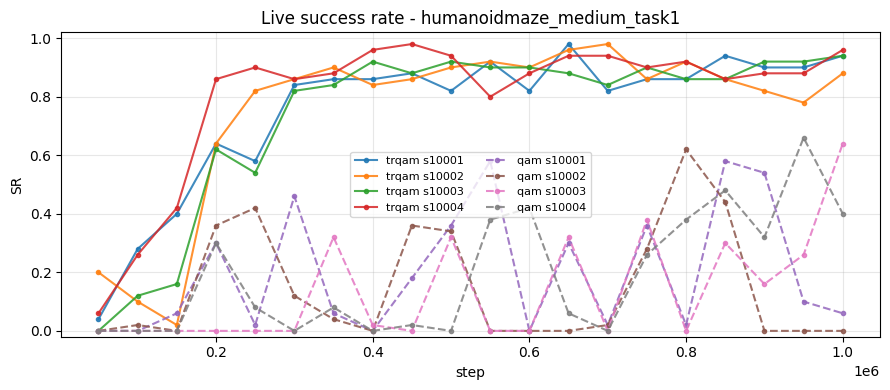

#### Recent worker log lines

**trqam_seed10001** (gpu 4):

```
100%|██████████| 50/50 [02:40<00:00,  3.21s/it]
Saved to exp_full/offline_rl_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/trqam_seed10001/params_1000000.pkl
```

**trqam_seed10002** (gpu 5):

```
100%|██████████| 50/50 [01:34<00:00,  1.89s/it]
Saved to exp_full/offline_rl_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/trqam_seed10002/params_1000000.pkl
```

**trqam_seed10003** (gpu 6):

```
100%|██████████| 50/50 [01:27<00:00,  1.76s/it]
Saved to exp_full/offline_rl_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/trqam_seed10003/params_1000000.pkl
```

**trqam_seed10004** (gpu 7):

```
100%|██████████| 50/50 [03:43<00:00,  4.47s/it]
Saved to exp_full/offline_rl_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/trqam_seed10004/params_1000000.pkl
```

**qam_seed10001** (gpu 4):

```
100%|██████████| 50/50 [02:25<00:00,  2.91s/it]
Saved to exp_full/offline_qam_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/qam_seed10001/params_1000000.pkl
```

**qam_seed10002** (gpu 5):

```
100%|██████████| 50/50 [02:26<00:00,  2.93s/it]
Saved to exp_full/offline_qam_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/qam_seed10002/params_1000000.pkl
```

**qam_seed10003** (gpu 6):

```
100%|██████████| 50/50 [01:40<00:00,  2.02s/it]
Saved to exp_full/offline_qam_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/qam_seed10003/params_1000000.pkl
```

**qam_seed10004** (gpu 7):

```
100%|██████████| 50/50 [02:05<00:00,  2.51s/it]
Saved to exp_full/offline_qam_humanoid_medium/humanoidmaze-medium-navigate-singletask-task1-v0/qam_seed10004/params_1000000.pkl
```

All launched runs have finished.

In [12]:
from IPython.display import clear_output
import time as _time

POLL_SECONDS = 30
while True:
    if RUN_REGISTRY:
        runs_for_logs = RUN_REGISTRY
        table = poll_status()
    else:  # kernel restarted: reconstruct from disk
        runs_for_logs = [{'name': s['name'], 'save_dir': s['save_dir'], 'gpu': s['gpu']} for s in RL_SPECS]
        table = disk_status_df()
    fig = plot_live_sr()
    clear_output(wait=True)
    display(Markdown(f'### Live Run Status - {TASK}  ({_time.strftime("%H:%M:%S")})'))
    display(table)
    if fig is not None:
        display(fig)
        plt.close(fig)
    display(Markdown('#### Recent worker log lines'))
    display_worker_logs(runs_for_logs, n=2)
    if all_runs_done():
        break
    _time.sleep(POLL_SECONDS)
display(Markdown('All launched runs have finished.'))

## 8. Live Run Status

Run this cell whenever the notebook output looks stale. It reads the CSV/checkpoint files from disk, so it works even when the Jupyter front-end is not replaying live output.

In [13]:
# Disk-based status snapshot. Safe after a kernel restart (reads files, not RUN_REGISTRY).
display(disk_status_df())

,name,algo,seed,gpu,done,hb_stage,hb_step,eval_step,latest_SR,latest_ckpt,updated
0,bc_seed10001,bc,10001,4,True,done,300000,300000,0.02,300000,2026-06-12 16:09:41
1,trqam_seed10001,trqam,10001,4,True,done,1000000,1000000,0.94,1000000,2026-06-12 20:49:35
2,trqam_seed10002,trqam,10002,5,True,done,1000000,1000000,0.88,1000000,2026-06-12 20:47:21
3,trqam_seed10003,trqam,10003,6,True,done,1000000,1000000,0.94,1000000,2026-06-12 20:47:11
4,trqam_seed10004,trqam,10004,7,True,done,1000000,1000000,0.96,1000000,2026-06-12 20:44:12
5,qam_seed10001,qam,10001,4,True,done,1000000,1000000,0.06,1000000,2026-06-12 21:09:47
6,qam_seed10002,qam,10002,5,True,done,1000000,1000000,0.00,1000000,2026-06-12 21:09:00
7,qam_seed10003,qam,10003,6,True,done,1000000,1000000,0.64,1000000,2026-06-12 21:08:38
8,qam_seed10004,qam,10004,7,True,done,1000000,1000000,0.40,1000000,2026-06-12 21:06:42


## 9. Optional Legacy Checkpoint Re-Eval

The main SR curve now comes from `eval.csv`, written every 1K RL steps during training. This optional cell is only for legacy runs that still have multiple saved `params_*.pkl` checkpoints and need SR recomputed after training.


In [14]:
# The orchestrated pipeline evaluates inline every 1K steps, so offline checkpoint
# re-evaluation is unnecessary. This cell is kept as a harmless placeholder.
RUN_CHECKPOINT_REEVAL = False
display(Markdown('Checkpoint re-evaluation is disabled. Every run writes `eval.csv` inline every 1K steps.'))

Checkpoint re-evaluation is disabled. Every run writes `eval.csv` inline every 1K steps.

## 10. Result Tables

Training logs are saved as `offline_agent.csv`, `online_agent.csv`, and `eval.csv`. For RL profiles, `eval.csv` contains the 1K-step SR curve.


In [15]:
RESULTS_DIR = Path(BC_SPEC['cfg_obj'].save_dir) / 'comparison' / TASK
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def load_run_eval(spec):
    path = Path(spec['save_dir']) / 'eval.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if df.empty or 'step' not in df.columns or 'success' not in df.columns:
        return None
    df = df[['step', 'success']].copy()
    df['step'] = pd.to_numeric(df['step'], errors='coerce')
    df['success'] = pd.to_numeric(df['success'], errors='coerce')
    return df.dropna().sort_values('step')


def aggregate_algo(algo):
    series = []
    for spec in RL_SPECS:
        if spec['kind'] != algo:
            continue
        df = load_run_eval(spec)
        if df is None:
            continue
        series.append(df.set_index('step')['success'].rename(spec['cfg_obj'].seed))
    if not series:
        return None
    matrix = pd.concat(series, axis=1).sort_index()
    agg = pd.DataFrame({
        'step': matrix.index.astype(int),
        'mean': matrix.mean(axis=1).values,
        'std': matrix.std(axis=1, ddof=0).values,
        'n': matrix.count(axis=1).values,
    }).reset_index(drop=True)
    return matrix, agg


AGG = {}
for algo in ALGOS:
    result = aggregate_algo(algo)
    if result is not None:
        AGG[algo] = result

final_rows = []
for algo, (matrix, agg) in AGG.items():
    last = agg.iloc[-1]
    final_rows.append({'algo': algo, 'final_step': int(last['step']),
                       'mean_SR': round(float(last['mean']), 4),
                       'std_SR': round(float(last['std']), 4),
                       'seeds': int(last['n'])})
final_df = pd.DataFrame(final_rows)
display(Markdown(f'### Final Success Rate - {TASK} (mean +/- std over seeds)'))
if not final_df.empty:
    display(final_df)
    final_df.to_csv(RESULTS_DIR / 'final_success_rate.csv', index=False)
    for algo, (matrix, agg) in AGG.items():
        agg.to_csv(RESULTS_DIR / f'{algo}_success_rate_curve.csv', index=False)
    display(Markdown(f'Saved aggregated CSVs to `{RESULTS_DIR}`.'))
else:
    display(Markdown('_No eval data found yet. Launch the pipeline (7A/7B) and let it produce `eval.csv`._'))

### Final Success Rate - humanoidmaze_medium_task1 (mean +/- std over seeds)

,algo,final_step,mean_SR,std_SR,seeds
0,trqam,1000000,0.930,0.0300,4
1,qam,1000000,0.275,0.2601,4


Saved aggregated CSVs to `exp_full/comparison/humanoidmaze_medium_task1`.

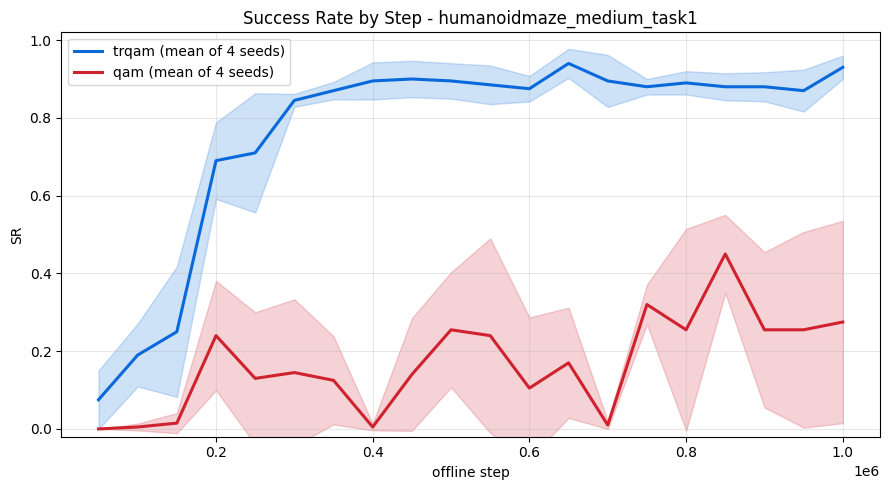

Saved comparison figure: `exp_full/comparison/humanoidmaze_medium_task1/trqam_vs_qam_success_rate.png`

In [16]:
report_figures = {}
if AGG:
    colors = {'trqam': '#0969da', 'qam': '#cf222e'}
    fig, ax = plt.subplots(figsize=(9, 5))
    for algo, (matrix, agg) in AGG.items():
        color = colors.get(algo)
        ax.plot(agg['step'], agg['mean'], linewidth=2.2, color=color,
                label=f'{algo} (mean of {int(agg["n"].max())} seeds)')
        ax.fill_between(agg['step'], agg['mean'] - agg['std'], agg['mean'] + agg['std'], alpha=0.2, color=color)
    ax.set_title(f'Success Rate by Step - {TASK}')
    ax.set_xlabel('offline step')
    ax.set_ylabel('SR')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    comparison_path = RESULTS_DIR / 'trqam_vs_qam_success_rate.png'
    fig.savefig(comparison_path, dpi=160, bbox_inches='tight')
    report_figures['TRQAM vs QAM Success Rate'] = comparison_path
    display(fig)
    plt.close(fig)
    display(Markdown(f'Saved comparison figure: `{comparison_path}`'))
else:
    display(Markdown('_No aggregated data to plot yet._'))

## 11. Automatically Generated Report

The final cell renders a report block from the current run and writes the same content to `report.html` inside the run directory. After a full run, this section contains the configuration, final evaluation metrics, recent training diagnostics, and saved plots.


algo,final_step,mean_SR,std_SR,seeds
trqam,1000000,0.930,0.0300,4
qam,1000000,0.275,0.2601,4

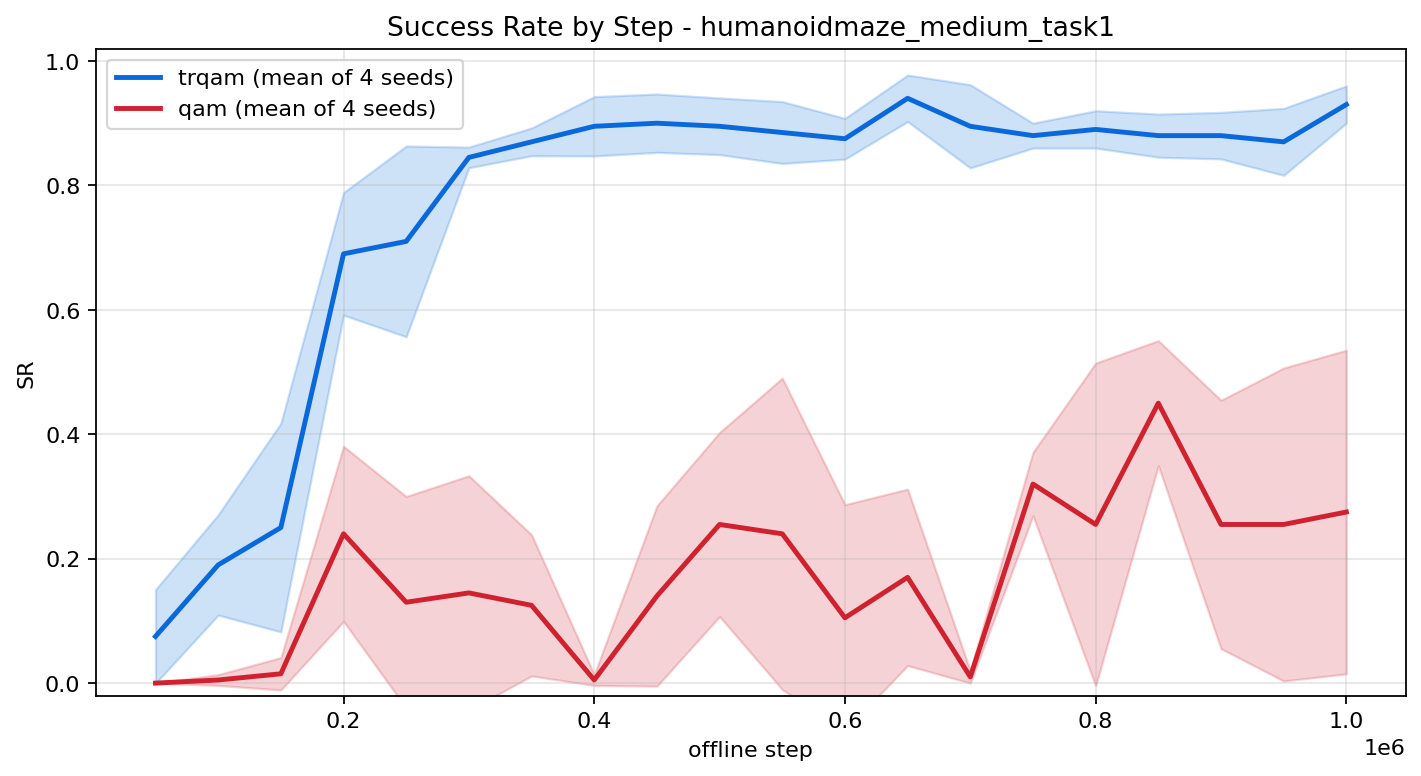

Report HTML saved to: `exp_full/comparison/humanoidmaze_medium_task1/report.html`

In [17]:
final_df = globals().get('final_df', pd.DataFrame())
report_figures = globals().get('report_figures', {})
results_dir = globals().get('RESULTS_DIR', Path('exp_full') / 'comparison' / TASK)
results_dir.mkdir(parents=True, exist_ok=True)


def _fmt(value):
    if isinstance(value, float):
        return f'{value:.4g}'
    return str(value)


def build_aggregate_report_html():
    cards = ''.join([
        f'<div class="trqam-kpi"><div class="label">Task</div><div class="value">{html.escape(TASK)}</div></div>',
        f'<div class="trqam-kpi"><div class="label">Seeds</div><div class="value">{html.escape(", ".join(map(str, SEEDS)))}</div></div>',
        f'<div class="trqam-kpi"><div class="label">Algorithms</div><div class="value">{html.escape(", ".join(ALGOS))}</div></div>',
    ])
    if not final_df.empty:
        for _, row in final_df.iterrows():
            cards += (f'<div class="trqam-kpi"><div class="label">{html.escape(str(row["algo"]))} final SR</div>'
                      f'<div class="value">{_fmt(row["mean_SR"])} +/- {_fmt(row["std_SR"])}</div></div>')

    table_html = (final_df.to_html(index=False, classes='report-table', border=0, escape=True)
                  if not final_df.empty else '<p class="trqam-muted">No aggregated results yet.</p>')

    figures_html = ''
    for title, path in report_figures.items():
        try:
            _src = 'data:image/png;base64,' + base64.b64encode(Path(path).read_bytes()).decode('ascii')
        except Exception:
            _src = html.escape(Path(path).name)
        figures_html += (f'<h3>{html.escape(title)}</h3>'
                         f'<img src="{_src}" alt="{html.escape(title)}" '
                         f'style="max-width:100%; border:1px solid #d0d7de; border-radius:6px;">')
    if not figures_html:
        figures_html = '<p class="trqam-muted">No figures generated yet.</p>'

    return f'''
<div class="trqam-report">
  <h2>TRQAM Experiment Report - {html.escape(TASK)}</h2>
  <p class="trqam-muted">Generated at: {html.escape(time.strftime('%Y-%m-%d %H:%M:%S'))}</p>

  <div class="trqam-callout">
    Two-stage pipeline: a shared BC flow policy, then off-policy fine-tuning with TRQAM and QAM across {len(SEEDS)} seeds each,
    run concurrently with inline 50-episode success-rate evaluation every 1K steps. The curve below shows mean +/- std over seeds.
  </div>

  <h3>Key Metrics</h3>
  <div class="trqam-kpi-grid">{cards}</div>

  <h3>Method Summary</h3>
  <p>
    TRQAM starts from a flow policy and improves its vector field using an adjoint target derived from the Q-function action gradient.
    A path-space KL trust region and a dual variable limit how far the fine-tuned policy can move from the pretrained base policy.
  </p>

  <h3>Final Success Rate (mean +/- std over seeds)</h3>
  {table_html}

  <h3>Figures</h3>
  {figures_html}

  <p class="trqam-muted">Results directory: {html.escape(str(results_dir))}</p>
</div>
'''


report_html = build_aggregate_report_html()
display(HTML(report_html))

full_html = f'''<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>TRQAM Report - {html.escape(TASK)}</title>
{REPORT_CSS}
</head>
<body style="max-width: 980px; margin: 32px auto; padding: 0 20px;">
{report_html}
</body>
</html>
'''
report_path = results_dir / 'report.html'
report_path.write_text(full_html, encoding='utf-8')
display(Markdown(f'Report HTML saved to: `{report_path}`'))

## 12. Second Task - Cube-Triple

Run this section **after** the humanoid task (Sections 7-11) finishes; it reuses the exact same orchestration with `TASK='cube_triple_task2'` (width 1024, `actor_layer_norm=True`, action-chunk horizon 1, the cube-triple 10M dataset). It writes a separate report under `exp_full/comparison/cube_triple_task2/`.

GPUs 4-7 are reused (BC done on the humanoid task is **not** shared - cube-triple trains its own BC first). Re-running is safe: completed runs are skipped, interrupted runs resume.

In [18]:
# Switch the pipeline to the cube-triple task and rebuild the specs (reuses all
# the orchestration defined above). Run this AFTER the humanoid task finishes.
TASK = 'cube_triple_task2'
RUN_PROFILE = TASK_PROFILES[TASK]['bc']
cfg = configure_profile(RUN_PROFILE)
agent_config = build_agent_config(cfg)
RUN_REGISTRY.clear()  # so the monitor/status below shows only the cube-triple runs
BC_SPEC, RL_SPECS, BC_CHECKPOINT = build_pipeline_specs()

if not cfg.ogbench_dataset_dir or not Path(cfg.ogbench_dataset_dir).expanduser().exists():
    display(Markdown(f'**Warning:** cube-triple dataset dir not found: `{cfg.ogbench_dataset_dir}`. '
                     'Download the 10M dataset into `~/.ogbench/data/cube-triple-play-10m-v0/` first.'))

plan_rows = [(BC_SPEC['name'], BC_SPEC['kind'], BC_SPEC['cfg_obj'].seed, BC_SPEC['gpu'],
              BC_SPEC['cfg_obj'].offline_steps, str(BC_SPEC['save_dir']))]
for spec in RL_SPECS:
    plan_rows.append((spec['name'], spec['kind'], spec['cfg_obj'].seed, spec['gpu'],
                      spec['cfg_obj'].offline_steps, str(spec['save_dir'])))
display(Markdown(f'### Cube-Triple Plan (TASK={TASK})'))
display(pd.DataFrame(plan_rows, columns=['name', 'algo', 'seed', 'gpu', 'offline_steps', 'save_dir']))
display(Markdown(f'Dataset: `{cfg.ogbench_dataset_dir}`  |  shared BC checkpoint: `{BC_CHECKPOINT}`'))

### Cube-Triple Plan (TASK=cube_triple_task2)

,name,algo,seed,gpu,offline_steps,save_dir
0,bc_seed10001,bc,10001,4,300000,exp_full/bc_pretrain_cube_triple/cube-triple-p...
1,trqam_seed10001,trqam,10001,4,1000000,exp_full/offline_rl_cube_triple/cube-triple-pl...
2,trqam_seed10002,trqam,10002,5,1000000,exp_full/offline_rl_cube_triple/cube-triple-pl...
3,trqam_seed10003,trqam,10003,6,1000000,exp_full/offline_rl_cube_triple/cube-triple-pl...
4,trqam_seed10004,trqam,10004,7,1000000,exp_full/offline_rl_cube_triple/cube-triple-pl...
5,qam_seed10001,qam,10001,4,1000000,exp_full/offline_qam_cube_triple/cube-triple-p...
6,qam_seed10002,qam,10002,5,1000000,exp_full/offline_qam_cube_triple/cube-triple-p...
7,qam_seed10003,qam,10003,6,1000000,exp_full/offline_qam_cube_triple/cube-triple-p...
8,qam_seed10004,qam,10004,7,1000000,exp_full/offline_qam_cube_triple/cube-triple-p...


Dataset: `/home/sanghyeok/.ogbench/data/cube-triple-play-10m-v0`  |  shared BC checkpoint: `exp_full/bc_pretrain_cube_triple/cube-triple-play-singletask-task2-v0/bc_seed10001/params_300000.pkl`

### 12A. Cube-Triple BC (run once)

In [19]:
import time as _time
from IPython.display import clear_output

bc_record = launch_run(BC_SPEC, wait=False)
if bc_record is None:  # already complete -> skipped
    if not BC_CHECKPOINT.exists():
        raise RuntimeError(f'BC marked complete but checkpoint missing: {BC_CHECKPOINT}')
    display(Markdown(f'BC already complete. Checkpoint: `{BC_CHECKPOINT}`'))
else:
    while bc_record['process'].poll() is None:
        hb = read_heartbeat(BC_SPEC['save_dir'])
        clear_output(wait=True)
        display(Markdown('### 7A. BC Pretraining (running on GPU ' + str(BC_SPEC['gpu']) + ')'))
        if hb:
            display(pd.DataFrame([{'stage': hb.get('stage'), 'step': hb.get('step'),
                                   'total': hb.get('total'), 'updated': hb.get('updated')}]))
        else:
            display(Markdown('Starting BC worker...'))
        tail = worker_log_tail(BC_SPEC['save_dir'], 4)
        if tail:
            display(Markdown(f'```\n{tail}\n```'))
        _time.sleep(30)
    bc_record['log_handle'].close()
    clear_output(wait=True)
    returncode = bc_record['process'].poll()
    if returncode != 0 or not BC_CHECKPOINT.exists():
        raise RuntimeError(
            f'BC failed (exit {returncode}) or checkpoint missing: {BC_CHECKPOINT}\n'
            f"Inspect the worker log: {BC_SPEC['save_dir']}/worker.log"
        )
    display(Markdown(f'BC finished. Checkpoint ready: `{BC_CHECKPOINT}`'))

- Skipping completed run `bc_seed10001` -> `exp_full/bc_pretrain_cube_triple/cube-triple-play-singletask-task2-v0/bc_seed10001`

BC already complete. Checkpoint: `exp_full/bc_pretrain_cube_triple/cube-triple-play-singletask-task2-v0/bc_seed10001/params_300000.pkl`

### 12B. Launch Cube-Triple RL (TRQAM x4 + QAM x4, 2 per GPU)

In [20]:
if not BC_CHECKPOINT.exists():
    raise RuntimeError('Run cell 7A first - the shared BC checkpoint was not found.')

launched = 0
for spec in RL_SPECS:
    if launch_run(spec, wait=False) is not None:
        launched += 1
display(Markdown(f'Launched {launched} concurrent run(s); skipped {len(RL_SPECS) - launched} already-complete.'))
display(poll_status())

- Skipping completed run `trqam_seed10001` -> `exp_full/offline_rl_cube_triple/cube-triple-play-singletask-task2-v0/trqam_seed10001`

- Skipping completed run `trqam_seed10002` -> `exp_full/offline_rl_cube_triple/cube-triple-play-singletask-task2-v0/trqam_seed10002`

- Skipping completed run `trqam_seed10003` -> `exp_full/offline_rl_cube_triple/cube-triple-play-singletask-task2-v0/trqam_seed10003`

- Skipping completed run `trqam_seed10004` -> `exp_full/offline_rl_cube_triple/cube-triple-play-singletask-task2-v0/trqam_seed10004`

- Skipping completed run `qam_seed10001` -> `exp_full/offline_qam_cube_triple/cube-triple-play-singletask-task2-v0/qam_seed10001`

- Skipping completed run `qam_seed10002` -> `exp_full/offline_qam_cube_triple/cube-triple-play-singletask-task2-v0/qam_seed10002`

- Skipping completed run `qam_seed10003` -> `exp_full/offline_qam_cube_triple/cube-triple-play-singletask-task2-v0/qam_seed10003`

- Skipping completed run `qam_seed10004` -> `exp_full/offline_qam_cube_triple/cube-triple-play-singletask-task2-v0/qam_seed10004`

Launched 0 concurrent run(s); skipped 8 already-complete.

""


### 12C. Monitor Until Completion

### Live Run Status - cube_triple_task2  (01:36:50)

,name,algo,seed,gpu,done,hb_stage,hb_step,eval_step,latest_SR,latest_ckpt,updated
0,bc_seed10001,bc,10001,4,True,done,300000,300000,0.00,300000,2026-06-13 11:54:11
1,trqam_seed10001,trqam,10001,4,True,done,1000000,1000000,0.30,1000000,2026-06-13 22:58:21
2,trqam_seed10002,trqam,10002,5,True,done,1000000,1000000,0.36,1000000,2026-06-13 23:01:54
3,trqam_seed10003,trqam,10003,6,True,done,1000000,1000000,0.38,1000000,2026-06-13 23:07:56
4,trqam_seed10004,trqam,10004,7,True,done,1000000,1000000,0.36,1000000,2026-06-13 22:47:40
5,qam_seed10001,qam,10001,4,True,done,1000000,1000000,0.06,1000000,2026-06-13 23:02:56
6,qam_seed10002,qam,10002,5,True,done,1000000,1000000,0.22,1000000,2026-06-13 23:04:26
7,qam_seed10003,qam,10003,6,True,done,1000000,1000000,0.20,1000000,2026-06-13 23:08:22
8,qam_seed10004,qam,10004,7,True,done,1000000,1000000,0.02,1000000,2026-06-13 22:53:55


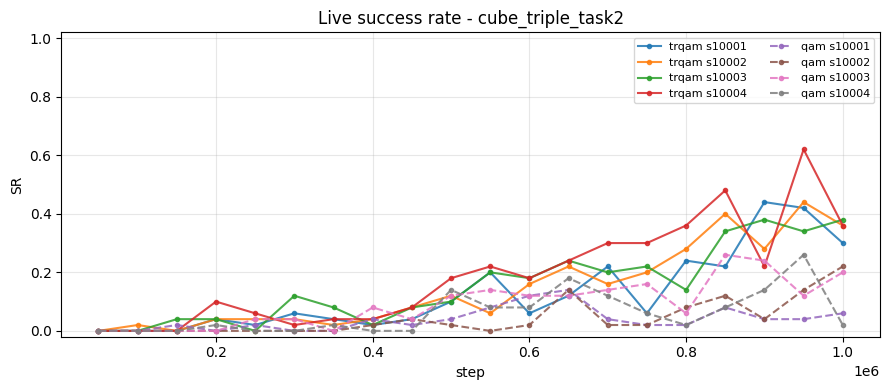

#### Recent worker log lines

**trqam_seed10001** (gpu 4):

```
100%|██████████| 50/50 [02:57<00:00,  3.56s/it]
Saved to exp_full/offline_rl_cube_triple/cube-triple-play-singletask-task2-v0/trqam_seed10001/params_1000000.pkl
```

**trqam_seed10002** (gpu 5):

```
100%|██████████| 50/50 [02:52<00:00,  3.46s/it]
Saved to exp_full/offline_rl_cube_triple/cube-triple-play-singletask-task2-v0/trqam_seed10002/params_1000000.pkl
```

**trqam_seed10003** (gpu 6):

```
100%|██████████| 50/50 [02:33<00:00,  3.07s/it]
Saved to exp_full/offline_rl_cube_triple/cube-triple-play-singletask-task2-v0/trqam_seed10003/params_1000000.pkl
```

**trqam_seed10004** (gpu 7):

```
100%|██████████| 50/50 [02:47<00:00,  3.35s/it]
Saved to exp_full/offline_rl_cube_triple/cube-triple-play-singletask-task2-v0/trqam_seed10004/params_1000000.pkl
```

**qam_seed10001** (gpu 4):

```
100%|██████████| 50/50 [02:54<00:00,  3.48s/it]
Saved to exp_full/offline_qam_cube_triple/cube-triple-play-singletask-task2-v0/qam_seed10001/params_1000000.pkl
```

**qam_seed10002** (gpu 5):

```
100%|██████████| 50/50 [02:44<00:00,  3.30s/it]
Saved to exp_full/offline_qam_cube_triple/cube-triple-play-singletask-task2-v0/qam_seed10002/params_1000000.pkl
```

**qam_seed10003** (gpu 6):

```
100%|██████████| 50/50 [02:42<00:00,  3.25s/it]
Saved to exp_full/offline_qam_cube_triple/cube-triple-play-singletask-task2-v0/qam_seed10003/params_1000000.pkl
```

**qam_seed10004** (gpu 7):

```
100%|██████████| 50/50 [03:09<00:00,  3.79s/it]
Saved to exp_full/offline_qam_cube_triple/cube-triple-play-singletask-task2-v0/qam_seed10004/params_1000000.pkl
```

All launched runs have finished.

In [21]:
from IPython.display import clear_output
import time as _time

POLL_SECONDS = 30
while True:
    if RUN_REGISTRY:
        runs_for_logs = RUN_REGISTRY
        table = poll_status()
    else:  # kernel restarted: reconstruct from disk
        runs_for_logs = [{'name': s['name'], 'save_dir': s['save_dir'], 'gpu': s['gpu']} for s in RL_SPECS]
        table = disk_status_df()
    fig = plot_live_sr()
    clear_output(wait=True)
    display(Markdown(f'### Live Run Status - {TASK}  ({_time.strftime("%H:%M:%S")})'))
    display(table)
    if fig is not None:
        display(fig)
        plt.close(fig)
    display(Markdown('#### Recent worker log lines'))
    display_worker_logs(runs_for_logs, n=2)
    if all_runs_done():
        break
    _time.sleep(POLL_SECONDS)
display(Markdown('All launched runs have finished.'))

### 12D. Cube-Triple Results & Report

In [22]:
RESULTS_DIR = Path(BC_SPEC['cfg_obj'].save_dir) / 'comparison' / TASK
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def load_run_eval(spec):
    path = Path(spec['save_dir']) / 'eval.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if df.empty or 'step' not in df.columns or 'success' not in df.columns:
        return None
    df = df[['step', 'success']].copy()
    df['step'] = pd.to_numeric(df['step'], errors='coerce')
    df['success'] = pd.to_numeric(df['success'], errors='coerce')
    return df.dropna().sort_values('step')


def aggregate_algo(algo):
    series = []
    for spec in RL_SPECS:
        if spec['kind'] != algo:
            continue
        df = load_run_eval(spec)
        if df is None:
            continue
        series.append(df.set_index('step')['success'].rename(spec['cfg_obj'].seed))
    if not series:
        return None
    matrix = pd.concat(series, axis=1).sort_index()
    agg = pd.DataFrame({
        'step': matrix.index.astype(int),
        'mean': matrix.mean(axis=1).values,
        'std': matrix.std(axis=1, ddof=0).values,
        'n': matrix.count(axis=1).values,
    }).reset_index(drop=True)
    return matrix, agg


AGG = {}
for algo in ALGOS:
    result = aggregate_algo(algo)
    if result is not None:
        AGG[algo] = result

final_rows = []
for algo, (matrix, agg) in AGG.items():
    last = agg.iloc[-1]
    final_rows.append({'algo': algo, 'final_step': int(last['step']),
                       'mean_SR': round(float(last['mean']), 4),
                       'std_SR': round(float(last['std']), 4),
                       'seeds': int(last['n'])})
final_df = pd.DataFrame(final_rows)
display(Markdown(f'### Final Success Rate - {TASK} (mean +/- std over seeds)'))
if not final_df.empty:
    display(final_df)
    final_df.to_csv(RESULTS_DIR / 'final_success_rate.csv', index=False)
    for algo, (matrix, agg) in AGG.items():
        agg.to_csv(RESULTS_DIR / f'{algo}_success_rate_curve.csv', index=False)
    display(Markdown(f'Saved aggregated CSVs to `{RESULTS_DIR}`.'))
else:
    display(Markdown('_No eval data found yet. Launch the pipeline (7A/7B) and let it produce `eval.csv`._'))

### Final Success Rate - cube_triple_task2 (mean +/- std over seeds)

,algo,final_step,mean_SR,std_SR,seeds
0,trqam,1000000,0.350,0.0300,4
1,qam,1000000,0.125,0.0865,4


Saved aggregated CSVs to `exp_full/comparison/cube_triple_task2`.

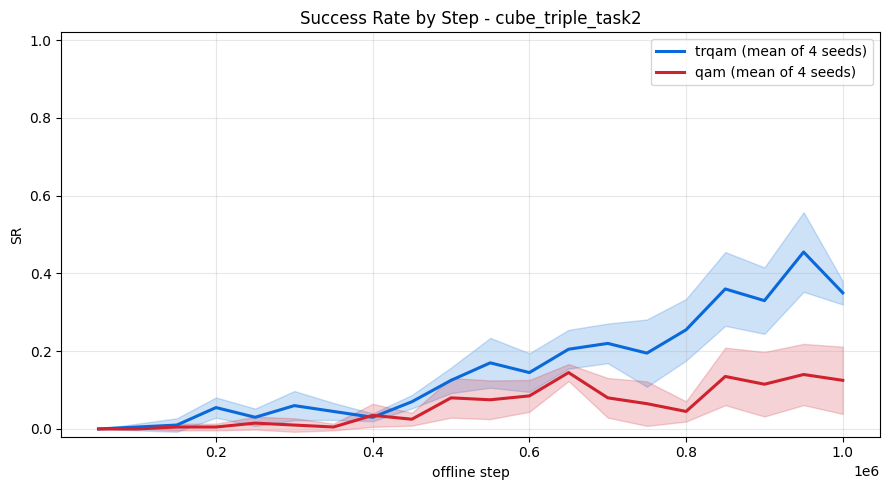

Saved comparison figure: `exp_full/comparison/cube_triple_task2/trqam_vs_qam_success_rate.png`

In [23]:
report_figures = {}
if AGG:
    colors = {'trqam': '#0969da', 'qam': '#cf222e'}
    fig, ax = plt.subplots(figsize=(9, 5))
    for algo, (matrix, agg) in AGG.items():
        color = colors.get(algo)
        ax.plot(agg['step'], agg['mean'], linewidth=2.2, color=color,
                label=f'{algo} (mean of {int(agg["n"].max())} seeds)')
        ax.fill_between(agg['step'], agg['mean'] - agg['std'], agg['mean'] + agg['std'], alpha=0.2, color=color)
    ax.set_title(f'Success Rate by Step - {TASK}')
    ax.set_xlabel('offline step')
    ax.set_ylabel('SR')
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    comparison_path = RESULTS_DIR / 'trqam_vs_qam_success_rate.png'
    fig.savefig(comparison_path, dpi=160, bbox_inches='tight')
    report_figures['TRQAM vs QAM Success Rate'] = comparison_path
    display(fig)
    plt.close(fig)
    display(Markdown(f'Saved comparison figure: `{comparison_path}`'))
else:
    display(Markdown('_No aggregated data to plot yet._'))

algo,final_step,mean_SR,std_SR,seeds
trqam,1000000,0.350,0.0300,4
qam,1000000,0.125,0.0865,4

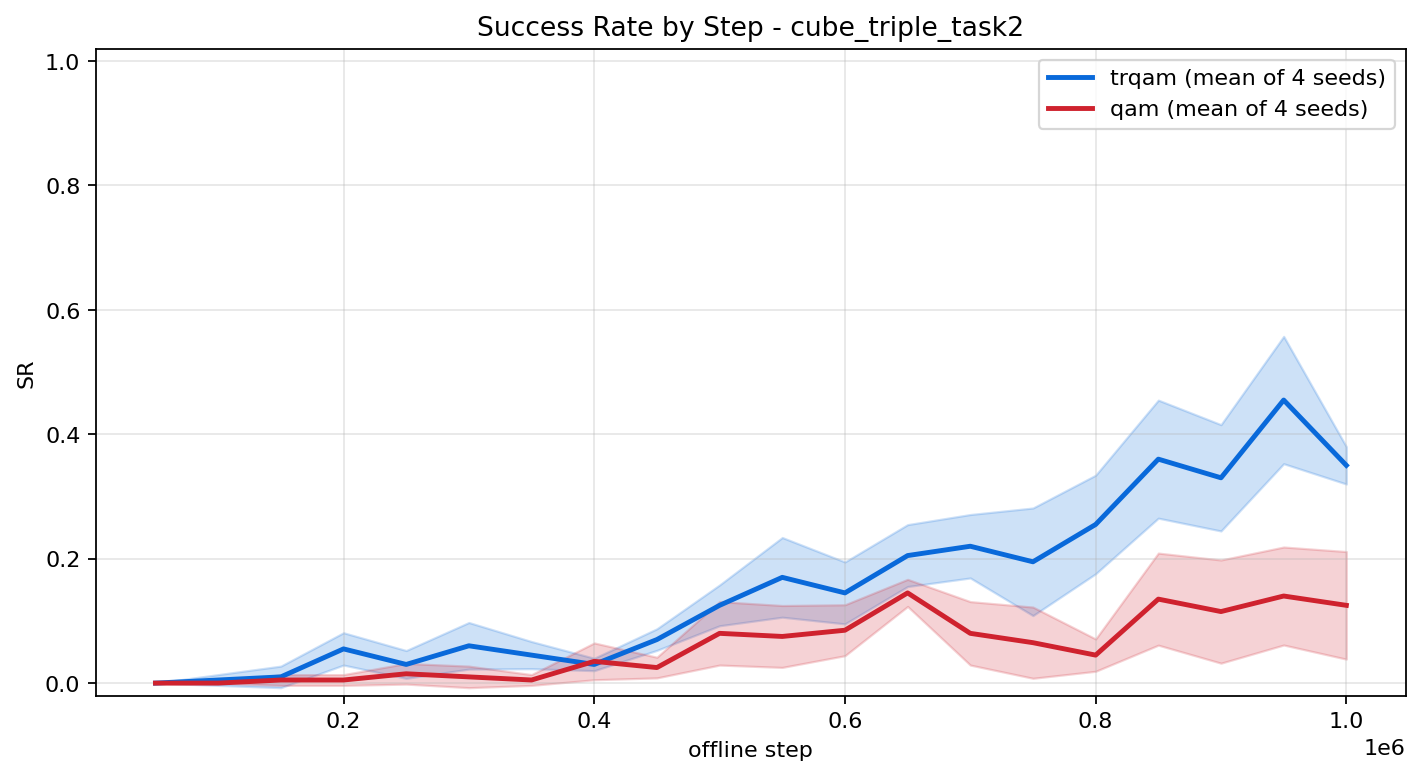

Report HTML saved to: `exp_full/comparison/cube_triple_task2/report.html`

In [24]:
final_df = globals().get('final_df', pd.DataFrame())
report_figures = globals().get('report_figures', {})
results_dir = globals().get('RESULTS_DIR', Path('exp_full') / 'comparison' / TASK)
results_dir.mkdir(parents=True, exist_ok=True)


def _fmt(value):
    if isinstance(value, float):
        return f'{value:.4g}'
    return str(value)


def build_aggregate_report_html():
    cards = ''.join([
        f'<div class="trqam-kpi"><div class="label">Task</div><div class="value">{html.escape(TASK)}</div></div>',
        f'<div class="trqam-kpi"><div class="label">Seeds</div><div class="value">{html.escape(", ".join(map(str, SEEDS)))}</div></div>',
        f'<div class="trqam-kpi"><div class="label">Algorithms</div><div class="value">{html.escape(", ".join(ALGOS))}</div></div>',
    ])
    if not final_df.empty:
        for _, row in final_df.iterrows():
            cards += (f'<div class="trqam-kpi"><div class="label">{html.escape(str(row["algo"]))} final SR</div>'
                      f'<div class="value">{_fmt(row["mean_SR"])} +/- {_fmt(row["std_SR"])}</div></div>')

    table_html = (final_df.to_html(index=False, classes='report-table', border=0, escape=True)
                  if not final_df.empty else '<p class="trqam-muted">No aggregated results yet.</p>')

    figures_html = ''
    for title, path in report_figures.items():
        try:
            _src = 'data:image/png;base64,' + base64.b64encode(Path(path).read_bytes()).decode('ascii')
        except Exception:
            _src = html.escape(Path(path).name)
        figures_html += (f'<h3>{html.escape(title)}</h3>'
                         f'<img src="{_src}" alt="{html.escape(title)}" '
                         f'style="max-width:100%; border:1px solid #d0d7de; border-radius:6px;">')
    if not figures_html:
        figures_html = '<p class="trqam-muted">No figures generated yet.</p>'

    return f'''
<div class="trqam-report">
  <h2>TRQAM Experiment Report - {html.escape(TASK)}</h2>
  <p class="trqam-muted">Generated at: {html.escape(time.strftime('%Y-%m-%d %H:%M:%S'))}</p>

  <div class="trqam-callout">
    Two-stage pipeline: a shared BC flow policy, then off-policy fine-tuning with TRQAM and QAM across {len(SEEDS)} seeds each,
    run concurrently with inline 50-episode success-rate evaluation every 1K steps. The curve below shows mean +/- std over seeds.
  </div>

  <h3>Key Metrics</h3>
  <div class="trqam-kpi-grid">{cards}</div>

  <h3>Method Summary</h3>
  <p>
    TRQAM starts from a flow policy and improves its vector field using an adjoint target derived from the Q-function action gradient.
    A path-space KL trust region and a dual variable limit how far the fine-tuned policy can move from the pretrained base policy.
  </p>

  <h3>Final Success Rate (mean +/- std over seeds)</h3>
  {table_html}

  <h3>Figures</h3>
  {figures_html}

  <p class="trqam-muted">Results directory: {html.escape(str(results_dir))}</p>
</div>
'''


report_html = build_aggregate_report_html()
display(HTML(report_html))

full_html = f'''<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>TRQAM Report - {html.escape(TASK)}</title>
{REPORT_CSS}
</head>
<body style="max-width: 980px; margin: 32px auto; padding: 0 20px;">
{report_html}
</body>
</html>
'''
report_path = results_dir / 'report.html'
report_path.write_text(full_html, encoding='utf-8')
display(Markdown(f'Report HTML saved to: `{report_path}`'))